In [1]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 41.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from matplotlib.collections import LineCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import networkx as nx
import math
import random
from itertools import combinations
from collections import Counter
from geopy.distance import geodesic
from tabulate import tabulate
import scipy.spatial.distance as distance
from decimal import Decimal, getcontext
from math import dist
import bz2
import geopandas as gpd
import time
import os
import pickle
from scipy import stats


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Carregamento de Estruturas Geoespaciais
Esta célula mapeia os caminhos absolutos do sistema operacional para os arquivos `.csv`. Utilizando a função `pd.read_csv`, os dados tabulares são transferidos do disco rígido para o espaço de memória RAM do Pandas, preparando-os para iteração e conversão em nós e arestas georreferenciadas.

In [4]:
df_europa = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Nodes_csv/nodes_EU.csv"
df_europa = pd.read_csv(df_europa, sep=',', encoding='utf-8')

df_asia = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Nodes_csv/nodes_AS.csv"
df_asia = pd.read_csv(df_asia, sep=',', encoding='utf-8')

df_america_do_sul = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Nodes_csv/nodes_SA.csv"
df_america_do_sul = pd.read_csv(df_america_do_sul, sep=',', encoding='utf-8')

df_africa = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Nodes_csv/nodes_AF.csv"
df_africa = pd.read_csv(df_africa, sep=',', encoding='utf-8')

df_oceania = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Nodes_csv/nodes_OC.csv"
df_oceania = pd.read_csv(df_oceania, sep=',', encoding='utf-8')

df_america_do_norte = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Nodes_csv/nodes_NA.csv"
df_america_do_norte = pd.read_csv(df_america_do_norte, sep=',', encoding='utf-8')




In [ ]:
df_africa

,inicial_node,final_node,continent_inicial,country_inicial,latitude_inicial,longitude_inicial,continent_final,country_final,latitude_final,longitude_final
0,N378644,N115908,AF,ZA,-26.20227,28.04363,AF,ZA,-26.20227,28.04363
1,N327529,N33581,AF,ZA,-26.20227,28.04363,AF,GW,12.00000,-15.00000
2,N276683,N218,AF,NaN,-19.97000,13.07000,AF,GW,12.00000,-15.00000
3,N26964,N119932,AF,MA,34.01325,-6.83255,AF,ZA,-33.92584,18.42322
4,N26964,N263181,AF,MA,34.01325,-6.83255,AF,ZA,-26.20227,28.04363
...,...,...,...,...,...,...,...,...,...,...
4032,N330763,N21194,AF,TZ,-1.33167,31.81222,AF,ZA,-33.92584,18.42322
4033,N1889998,N21194,AF,SN,13.06670,-12.71670,AF,ZA,-33.92584,18.42322
4034,N1890041,N21194,AF,TZ,-1.33167,31.81222,AF,ZA,-33.92584,18.42322
4035,N1888152,N21194,AF,TZ,-1.33167,31.81222,AF,ZA,-33.92584,18.42322


### Geração do Grafo de nós geolocalizados - Redes Reais
O código instancia um grafo direcionado (`nx.DiGraph()`) vazio e itera sobre as linhas do DataFrame correspondente ao continente. Para cada registro, os atributos geográficos (latitude e longitude) são ancorados nos nós de origem e destino, e uma aresta é desenhada para representar fisicamente a existência de um cabo de fibra ótica conectando esses roteadores.

In [5]:
### Criação da Rede de Fibra
'''
G = nx.DiGraph()

# Adicionar todos os nós e arestas ao grafo
for _, row in df_asia.iterrows():
    # Adicionar nó inicial com atributos
    G.add_node(row['inicial_node'],
               continent=row['continent_inicial'],
               country=row['country_inicial'],
               longitude_inicial=row['longitude_inicial'],
               latitude_inicial=row['latitude_inicial'])


    # Adicionar nó final com atributos
    G.add_node(row['final_node'],
               continent=row['continent_final'],
               country=row['country_final'],
               longitude_final=row['longitude_final'],
               latitude_final=row['latitude_final'])

    # Adicionar aresta
    G.add_edge(row['inicial_node'], row['final_node'])

print(G.number_of_nodes())
print(G.number_of_edges())

pos = dict()

for node in G.nodes:
    lon_inicial = G.nodes[node]["longitude_inicial"]
    lat_inicial = G.nodes[node]["latitude_inicial"]
    lon_final = G.nodes[node]["longitude_final"]
    lat_final = G.nodes[node]["latitude_final"]

    pos[node] = (lon_inicial,lon_final, lat_inicial,lat_final) '''

def _transmissivity(d, gamma):  # noqa: F811
    """."""
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    """."""
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p

G = nx.from_pandas_edgelist(
    df_europa,
    source='inicial_node',
    target='final_node',
    create_using=nx.DiGraph()
)

# Cria um dataframe com as informações dos nós de ORIGEM
df_source = df_europa[['inicial_node', 'continent_inicial', 'country_inicial', 'latitude_inicial', 'longitude_inicial']].rename(
    columns={'inicial_node': 'node_id', 'continent_inicial': 'continent', 'country_inicial': 'country',
             'latitude_inicial': 'lat', 'longitude_inicial': 'lon'}
)
# Cria um dataframe com as informações dos nós de DESTINO
df_target = df_europa[['final_node', 'continent_final', 'country_final', 'latitude_final', 'longitude_final']].rename(
    columns={'final_node': 'node_id', 'continent_final': 'continent', 'country_final': 'country',
             'latitude_final': 'lat', 'longitude_final': 'lon'}
)
# Combina os dois e remove duplicatas para ter uma lista única de nós
df_nodes_completos = pd.concat([df_source, df_target]).drop_duplicates(subset=['node_id']).reset_index(drop=True)
print(f"-> Catálogo de atributos únicos para {len(df_nodes_completos)} nós preparado.")



atributos_info = df_nodes_completos.set_index('node_id')[['continent', 'country']].to_dict('index')
nx.set_node_attributes(G, atributos_info)

# atributo 'pos'
pos_attributes = df_nodes_completos.set_index('node_id')[['lon', 'lat']].to_dict('index')
# Transforma o dicionário para o formato {node_id: (lon, lat)} que o 'pos' espera
pos_final = {node: (data['lon'], data['lat']) for node, data in pos_attributes.items()}
nx.set_node_attributes(G, pos_final, name='pos')

pos = nx.get_node_attributes(G, 'pos')
print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())
print(f"Nós com mais conexões :",sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10])


def rede_photonica(g_f, gamma, n_p):
    """
    Constrói uma rede fotônica a partir de uma rede de transporte.

    Parâmetros:
    g_f (nx.Graph): Rede de transporte.
    gamma (float): Coeficiente de atenuação.
    n_p (int): Número de fótons.

    Retorna:
    g_f (nx.Graph): Rede de transporte original.
    g_p (nx.Graph): Rede fotônica construída.
    """
    g_p = nx.Graph()
    g_p.add_nodes_from(g_f.nodes())
    nx.set_node_attributes(g_f, pos, name="pos")
    nx.set_node_attributes(g_p, pos, name="pos")

    metric = math.dist
    def dist(u, v):
        return metric(pos[u], pos[v])

    print(f"  Construindo a rede fotônica...")
    total_edges = g_f.number_of_edges()
    start_loop2 = time.time() # INÍCIO DO CONTADOR INTERNO

    for i, edge in enumerate(g_f.edges):

        if i % 20000 == 0 and i > 0:
            print(f"    -> Verificando aresta {i}/{total_edges}")

        d_uv = dist(edge[0], edge[1])
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = np.random.rand()
        if p_uv >= p:
            g_p.add_edge(*edge)

    end_loop2 = time.time() # FIM DO CONTADOR INTERNO
    print(f"  -> Concluído em {end_loop2 - start_loop2:.2f} segundos.")

    return g_f, g_p


g_fiber_real, g_photon_real = rede_photonica(G, gamma=0.2, n_p=1000)
pos = nx.get_node_attributes(g_fiber_real, 'pos')

print("Rede de fibra:", g_fiber_real.number_of_nodes(), "nós e", g_fiber_real.number_of_edges(), "arestas.")
print("Rede fotônica:", g_photon_real.number_of_nodes(), "nós e", g_photon_real.number_of_edges(), "arestas.")





-> Catálogo de atributos únicos para 31430 nós preparado.
Nós: 31430
Arestas: 141533
Nós com mais conexões : [('N325278', 1385), ('N382829', 1222), ('N385586', 1197), ('N356875', 1178), ('N368965', 1117), ('N303971', 1102), ('N327715', 1088), ('N361297', 1088), ('N361238', 1073), ('N345316', 1056)]
  Construindo a rede fotônica...
    -> Verificando aresta 20000/141533
    -> Verificando aresta 40000/141533
    -> Verificando aresta 60000/141533
    -> Verificando aresta 80000/141533
    -> Verificando aresta 100000/141533
    -> Verificando aresta 120000/141533
    -> Verificando aresta 140000/141533
  -> Concluído em 0.82 segundos.
Rede de fibra: 31430 nós e 141533 arestas.
Rede fotônica: 31430 nós e 125327 arestas.


### Salvar os grafos
Após o processamento de conversão de dados tabulares em propriedades de grafos, o objeto NetworkX construído é serializado utilizando a biblioteca `pickle`.Gera um *checkpoint* no disco rígido, permitindo que a infraestrutura topológica seja recarregada instantaneamente em execuções futuras sem a necessidade de reprocessar o *parsing* do Pandas.

In [6]:
path_base = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)"
caminho_arquivo_gf = os.path.join(path_base, 'g_fiber_real_EU.pickle')
caminho_arquivo_gp = os.path.join(path_base, 'g_photon_real_EU.pickle')

# --- Salvar dados da Rede de Fibra (g_f) ---
try:
    # 2. Abrimos um arquivo em modo "write binary" (wb)
    with open(caminho_arquivo_gf, 'wb') as f:
        # 3. Usamos pickle.dump para salvar o objeto no arquivo
        pickle.dump(g_fiber_real, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo de fibra (g_fiber_real) salvo em: {caminho_arquivo_gf}")

    # --- Salvar dados da Rede Fotônica (g_p) ---
    with open(caminho_arquivo_gp, 'wb') as f:
        pickle.dump(g_photon_real, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo fotônico (g_photon_real) salvo em: {caminho_arquivo_gp}")

    print("\n--- Processo de salvamento concluído! ---")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

-> Grafo de fibra (g_fiber_real) salvo em: /content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)/g_fiber_real_EU.pickle
-> Grafo fotônico (g_photon_real) salvo em: /content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)/g_photon_real_EU.pickle

--- Processo de salvamento concluído! ---


### Distribuição de Graus e Power-Law
Esta célula verifica a propriedade "Livre de Escala" (*Scale-Free*) das redes reais. A função desenvolvida recebe um grafo, extrai o número de conexões (k) de cada roteador e plota o histograma normalizado em escala log-log ($P(k)$ vs $k$). Adicionalmente, utiliza a regressão linear de mínimos quadrados do SciPy para traçar o *fit* da lei de potência, retornando visualmente o coeficiente angular da rede ($-\gamma$).

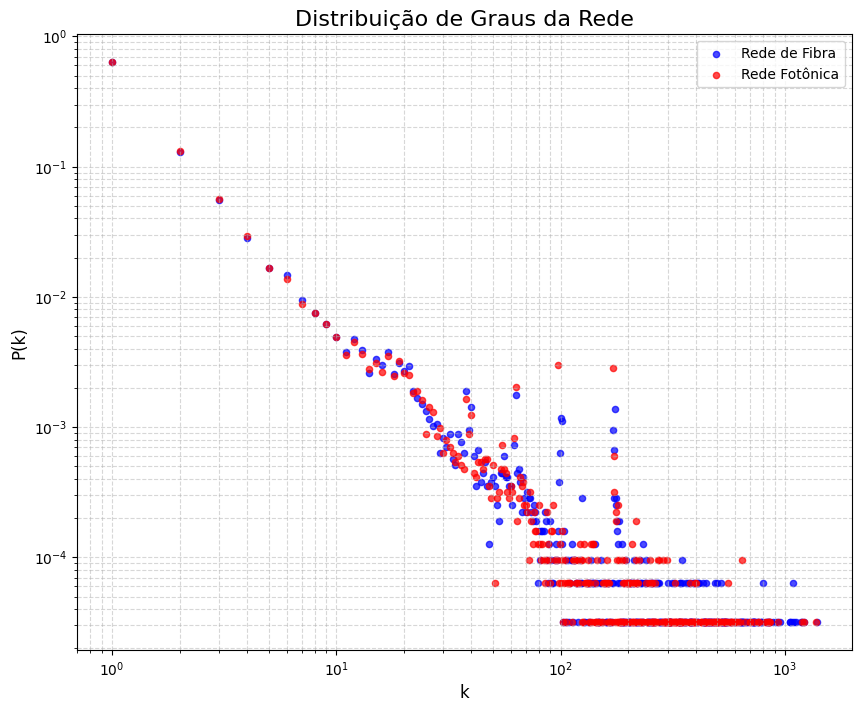

In [ ]:
def plotar_distribuicao_graus(ax, G, color, label):
    """
    Função auxiliar para calcular e plotar a distribuição de graus de um grafo.
    """
    # Pega o grau de cada nó no grafo
    degrees = [val for (node, val) in G.degree()]

    # Conta quantas vezes cada grau aparece
    degree_counts = Counter(degrees)

    # Separa os graus (k) e suas contagens
    k, count = zip(*degree_counts.items())

    # Calcula a probabilidade P(k) = (nós com grau k) / (total de nós)
    pk = [c / G.number_of_nodes() for c in count]

    # Plota k vs P(k) em um gráfico de dispersão
    ax.scatter(k, pk, color=color, label=label, alpha=0.7, s=20) # s é o tamanho dos pontos

# Cria a figura e os eixos para o plot
fig, ax = plt.subplots(figsize=(15, 6))

# Plota a distribuição para a rede de fibra
plotar_distribuicao_graus(ax, g_fiber_real, color='blue', label='Rede de Fibra')

# Plota a distribuição para a rede fotônica no mesmo gráfico
plotar_distribuicao_graus(ax, g_photon_real, color='red', label='Rede Fotônica')

# Define a escala dos eixos para logarítmica
ax.set_xscale('log')
ax.set_yscale('log')

# Adiciona títulos e legendas
ax.set_title("Distribuição de Graus da Rede", fontsize=16)
ax.set_ylabel("P(k)", fontsize=12)
ax.set_xlabel("k", fontsize=12)
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig("Distribuição de Graus.pdf", format='pdf', dpi= 300, bbox_inches='tight')
# Exibe o gráfico
plt.show()


### Soares-Samurai
Inicialmente, definem-se as fórmulas de Transmissividade da fibra e a probabilidade dos phtons estarem emanharados. Em seguida, a função `soares_samurai` gera um modelo topológico que atende aos parâmetros geográficos. O algoritmo distribui $n$ nós em um disco de referência, forma as ligações da fibra sobre cada aresta com base na distância calculada. Se o sorteio probabilístico for menor que a chance do fóton não decair, a aresta de emaranhamento quântico é validada.

In [ ]:
def _transmissivity(d, gamma):
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p


def soares_samurai(n, m, radius, alpha_a, gamma, n_p, seed = 0):
    """."""
    if m < 1 or m >= n:
        raise Exception("network must have m >= 1 and m < n")
    if alpha_a < 0:
        raise Exception("alpha_a must satisfy alpha_a >= 0")

    # Positioning of nodes
    radius_rand = np.sqrt(np.random.uniform(0, radius**2, n))
    theta_rand = np.random.uniform(0, 2 * np.pi, n)
    pos_x = radius_rand * np.cos(theta_rand)
    pos_y = radius_rand * np.sin(theta_rand)
    pos = np.vstack([pos_x, pos_y]).T

    g_f = nx.complete_graph(m + 1)

    # Positioning of incoming nodes
    print(f"  Construindo a rede de fibra (preferential attachment)...")
    start_loop1 = time.time() # INÍCIO DO CONTADOR INTERNO 1
    for new_node in range(m + 1, n):
        if new_node % 1000 == 0:
            print(f"    -> Adicionando nó {new_node}/{n}")

        degrees = np.array(list(dict(g_f.degree()).values()))
        dist = pos[:new_node] - pos[new_node]
        r_ij = np.sqrt(np.sum(dist**2, axis=1)) ** (-alpha_a)
        prob = degrees * r_ij
        prob_norm = prob / np.sum(prob)

        chosen = np.random.choice(
            list(g_f.nodes), size=m, replace=False, p=prob_norm
        )
        for node in chosen:
            g_f.add_edge(node, new_node)
    end_loop1 = time.time() # FIM DO CONTADOR INTERNO 1
    print(f"  -> Concluído em {end_loop1 - start_loop1:.2f} segundos.")

    # Creates the photonic network from fiber optics network
    g_p = nx.Graph()
    g_p.add_nodes_from(g_f.nodes())
    pos = {node: (pos_x[node], pos_y[node]) for node in range(n)}
    nx.set_node_attributes(g_f, pos, name="pos")
    nx.set_node_attributes(g_p, pos, name="pos")

    metric = math.dist
    def dist(u, v):
        return metric(pos[u], pos[v])

    print(f"  Construindo a rede fotônica...")
    total_edges = g_f.number_of_edges()
    start_loop2 = time.time() # INÍCIO DO CONTADOR INTERNO 2
    for i, edge in enumerate(g_f.edges):
        if i % 20000 == 0 and i > 0:
            print(f"    -> Verificando aresta {i}/{total_edges}")

        d_uv = dist(edge[0], edge[1])
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = np.random.rand()
        if p_uv >= p:
            g_p.add_edge(*edge)
    end_loop2 = time.time() # FIM DO CONTADOR INTERNO 2
    print(f"  -> Concluído em {end_loop2 - start_loop2:.2f} segundos.")

    return g_f, g_p





n = 2032
R = 3109.19
m = 2
gamma = 0.2
n_p = 1000
alpha_a = 5

print("--- Executando o modelo soares_samurai ---")
start_total_soares = time.time() # INÍCIO DO CONTADOR GERAL
g_f, g_p = soares_samurai(n, m, R, alpha_a, gamma, n_p, seed=0)
end_total_soares = time.time() # FIM DO CONTADOR GERAL
pos = nx.get_node_attributes(g_f, 'pos')

duration_soares = end_total_soares - start_total_soares
print(f"--- Modelo soares_samurai finalizado em {duration_soares:.2f} segundos ({duration_soares/60:.2f} minutos) ---\n")

print("Nós(rede fibra):", g_f.number_of_nodes(), "Arestas:", g_f.number_of_edges())
print("Nós(rede photonica):", g_p.number_of_nodes(), "Arestas:", g_p.number_of_edges())


--- Executando o modelo soares_samurai ---
  Construindo a rede de fibra (preferential attachment)...
    -> Adicionando nó 1000/2032
    -> Adicionando nó 2000/2032
  -> Concluído em 4.32 segundos.
  Construindo a rede fotônica...
  -> Concluído em 0.03 segundos.
--- Modelo soares_samurai finalizado em 4.42 segundos (0.07 minutos) ---

Nós(rede fibra): 2032 Arestas: 4061
Nós(rede photonica): 2032 Arestas: 2547


In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"
caminho_arquivo_gf = os.path.join(path_base, 'soares_fibra(AF).pickle')
caminho_arquivo_gp = os.path.join(path_base, 'soares_photonica(AF).pickle')

# --- Salvar dados da Rede de Fibra (g_f) ---
try:
    # 2. Abrimos um arquivo em modo "write binary" (wb)
    with open(caminho_arquivo_gf, 'wb') as f:
        # 3. Usamos pickle.dump para salvar o objeto no arquivo
        pickle.dump(g_f, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo de fibra (g_f) salvo em: {caminho_arquivo_gf}")

    # --- Salvar dados da Rede Fotônica (g_p) ---
    with open(caminho_arquivo_gp, 'wb') as f:
        pickle.dump(g_p, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo fotônico (g_p) salvo em: {caminho_arquivo_gp}")

    print("\n--- Processo de salvamento concluído! ---")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

-> Grafo de fibra (g_f) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa\soares_fibra(AF).pickle
-> Grafo fotônico (g_p) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa\soares_photonica(AF).pickle

--- Processo de salvamento concluído! ---


### Waxman-Samurai
Esta célula parametriza o clássico algoritmo de roteamento de **Waxman** sobre a infraestrutura da Internet Quântica. A probabilidade de dois nós geográficos se conectarem decai exponencialmente conforme a distância euclidiana entre eles cresce (modulada pelas constantes $\alpha_L$ e $\beta$). Posteriormente, aplica-se a mesma camada física de atenuação fotônica da fibra para definir quais destas conexões Waxman clássicas conseguem suportar uma conexão quântica estável.

In [ ]:
def _transmissivity(d, gamma):
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p

def waxman_samurai(nr_nodes, radius, alphaL, beta, gamma, n_p, seed = 0):
    """."""
    g_fiber = nx.empty_graph(nr_nodes)
    g_photonic = nx.empty_graph(nr_nodes)

    radius_rand = np.sqrt(np.random.uniform(0, radius**2, nr_nodes))
    theta_rand = np.random.uniform(0, 2 * np.pi, nr_nodes)
    pos_x = radius_rand * np.cos(theta_rand)
    pos_y = radius_rand * np.sin(theta_rand)
    pos = {node: (pos_x[node], pos_y[node]) for node in g_fiber}

    nx.set_node_attributes(g_fiber, pos, "pos")
    nx.set_node_attributes(g_photonic, pos, "pos")

    metric = math.dist
    def dist(u, v):
        return metric(pos[u], pos[v])
    def should_join(pair):
        return np.random.rand() < beta * np.exp(-dist(*pair) / (alphaL))

    print("  Construindo a rede de fibra (modelo Waxman)")
    all_possible_edges = combinations(g_fiber, 2)
    total_combinations = (nr_nodes * (nr_nodes - 1)) // 2

    start_loop1_waxman = time.time() # INÍCIO DO CONTADOR INTERNO 1
    for i, pair in enumerate(all_possible_edges):
        if i % 5_000_000 == 0 and i > 0:
            print(f"    -> Verificando par de nós {i:,}/{total_combinations:,}")

        if should_join(pair):
            g_fiber.add_edge(*pair)
    end_loop1_waxman = time.time() # FIM DO CONTADOR INTERNO 1
    print(f"  -> Concluído em {end_loop1_waxman - start_loop1_waxman:.2f} segundos.")

    print("  Construindo a rede fotônica...")
    total_edges = g_fiber.number_of_edges()
    start_loop2_waxman = time.time() # INÍCIO DO CONTADOR INTERNO 2
    for i, edge in enumerate(g_fiber.edges):
        if i % 20000 == 0 and i > 0:
            print(f"    -> Verificando aresta {i}/{total_edges}")

        d_uv = dist(edge[0], edge[1])
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = np.random.rand()
        if p_uv >= p:
            g_photonic.add_edge(*edge)
    end_loop2_waxman = time.time() # FIM DO CONTADOR INTERNO 2
    print(f"  -> Concluído em {end_loop2_waxman - start_loop2_waxman:.2f} segundos.")

    return g_fiber, g_photonic

# ========================================================================
# CHAMADA DA SEGUNDA FUNÇÃO
# =================================
N = 43957
R = 2803.68
alphaL = 226
beta = 1
gamma = 0.2
n_p = 1000

print("--- Executando o modelo waxman_samurai ---")
start_total_waxman = time.time()
G_fiber, G_photonic = waxman_samurai(N, R, alphaL, beta, gamma, n_p, seed = 0)
end_total_waxman = time.time()
pos = nx.get_node_attributes(G_fiber, 'pos')

duration_waxman = end_total_waxman - start_total_waxman
print(f"--- Modelo waxman_samurai finalizado em {duration_waxman:.2f} segundos ({duration_waxman/60:.2f} minutos) ---")

print("Nós(rede fibra):", G_fiber.number_of_nodes(), "Arestas:", G_fiber.number_of_edges())
print("Nós(rede photonica):", G_photonic.number_of_nodes(), "Arestas:", G_photonic.number_of_edges())

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Oceania\samuraí_fibra(OC).pickle"
path_base2 = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Oceania\samuraí_photonica(OC).pickle"


caminho_arquivo_gf = os.path.join(path_base)
caminho_arquivo_gp = os.path.join(path_base2)

print("Carregando arquivos .pickle...")

try:
    # Abre o arquivo em modo "read binary" (rb)
    with open(caminho_arquivo_gf, 'rb') as f:
        G_fibra_carregado = pickle.load(f)

    with open(caminho_arquivo_gp, 'rb') as f:
        G_photonic_carregado = pickle.load(f)

    print("-> Grafos carregados com sucesso!")

    # Verificação
    print("\n--- Verificando os Grafos Carregados ---")
    print(f"Rede de fibra carregada: Nós: {G_fibra_carregado.number_of_nodes()}, Arestas: {G_fibra_carregado.number_of_edges()}")
    print(f"Rede fotônica carregada: Nós: {G_photonic_carregado.number_of_nodes()}, Arestas: {G_photonic_carregado.number_of_edges()}")

except Exception as e:
    print(f"Ocorreu um erro ao carregar os arquivos: {e}")

Carregando arquivos .pickle...
-> Grafos carregados com sucesso!

--- Verificando os Grafos Carregados ---
Rede de fibra carregada: Nós: 5540, Arestas: 475522
Rede fotônica carregada: Nós: 5540, Arestas: 90674


### Scale-Free
Modelo gerador de redes *Scale-Free* (Livres de Escala, orientadas à Preferential Attachment) limitadas a um domínio espacial circular. O algoritmo força o surgimento natural de *hubs* (grandes aglomeradores de tráfego) seguindo uma estrutura estritamente atrelada a uma distribuição P(k) que segue a lei de potência, para posteriormente aplicar o teste estocástico de viabilidade quântica da fibra com limiar de fótons ($n_p$).

In [ ]:
def _transmissivity(d, gamma):
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p

def scale_free_on_disc(
    n, radius, scale, exponent, gamma, n_p, k_domain=(3, 1e4), seed=None
):
    """Gera redes scale-free em um disco com acompanhamento de processo."""
    rng = np.random.default_rng(seed)
    m, K = k_domain

    print("  Iniciando a geração da rede...")

    def _generate_connectivity(random_val):
        """Cumulative distribution function for P(k)=Ck^{-exponent}."""
        k = round(m * (1 - random_val) ** (1 / (1 - exponent)))
        return min(max(k, m), K)

    # Etapa de posicionamento (rápida, não precisa de print)
    radius_rand = np.sqrt(rng.uniform(0, radius**2, n))
    theta_rand = rng.uniform(0, 2 * np.pi, n)
    pos_x = radius_rand * np.cos(theta_rand)
    pos_y = radius_rand * np.sin(theta_rand)
    pos = np.vstack([pos_x, pos_y]).T

    # --- ACOMPANHAMENTO 1: Geração de Conectividade ---
    print(f"  (1/4) Gerando conectividade para {n} nós...")
    random_list = rng.random(pos.shape[0])
    # Convertido para loop 'for' para permitir o print
    connectivity = []
    for i, val in enumerate(random_list):
        if (i + 1) % 5000 == 0 or i == n - 1:
            print(f"    -> Conectividade para o nó {i + 1}/{n}")
        connectivity.append(_generate_connectivity(val))

    g_f_free = nx.Graph()
    # Adiciona nós (etapa rápida)
    for i, pos_i in enumerate(pos):
        g_f_free.add_node(i, pos=pos_i, k=connectivity[i])
    print("  -> Nós adicionados ao grafo.")

    # --- ACOMPANHAMENTO 2: Criação da Rede de Fibra ---
    print(f"  (2/4) Criando arestas da rede de fibra (pode demorar)...")
    for i, pos_i in enumerate(pos):
        if (i + 1) % 1000 == 0 or i == n - 1:
            print(f"    -> Processando vizinhança do nó {i + 1}/{n}")

        k_i = connectivity[i]
        r_i = scale * np.sqrt(k_i)
        distances = np.linalg.norm(pos - pos_i, axis=1)

        neighbors = np.argsort(distances)
        neighbors = neighbors[
            (distances[neighbors] <= r_i) & (distances[neighbors] > 0)
        ]

        for j in neighbors:
            if g_f_free.degree[i] < k_i and g_f_free.degree[j] < connectivity[j]:
                g_f_free.add_edge(i, j)

    print("  -> Rede de fibra criada.")

    # Etapa de preparação da rede fotônica (rápida)
    g_p_free = nx.Graph()
    g_p_free.add_nodes_from(g_f_free.nodes())

    pos_dict = {i: (x, y) for i, (x, y) in enumerate(pos)}
    nx.set_node_attributes(g_f_free, pos_dict, "pos")
    nx.set_node_attributes(g_p_free, pos_dict, "pos")

    # Renomeando math.dist para evitar conflito
    metric = math.dist
    def dist(u, v):
        return metric(pos_dict[u], pos_dict[v])

    # --- ACOMPANHAMENTO 3: Criação da Rede Fotônica ---
    print(f"  (3/4) Criando arestas da rede fotônica...")
    total_edges = g_f_free.number_of_edges()
    for i, (u, v) in enumerate(g_f_free.edges):
        if (i + 1) % 20000 == 0 or (i + 1) == total_edges:
            print(f"    -> Processando aresta fotônica {i + 1}/{total_edges}")

        d_uv = dist(u, v)
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = rng.random()
        if p_uv >= p:
            g_p_free.add_edge(u, v)

    print("  (4/4) Finalizando a criação dos grafos.")
    return g_f_free, g_p_free


n = 2032
R = 3109.19  # Radius of the disc
lambda_ = 2.5  # Distribution exponent
m = 3  # Minimum connectivity
K = 1e4  # Maximum connectivity
A = 100  # Model Constant
gamma = 0.2  # Fiber loss coefficient [dB/km]
n_p = 1000  # Number of photons

g_f_free, g_p_free = scale_free_on_disc(n=n, radius=R, scale=A, exponent=lambda_, gamma=gamma, n_p=1000, k_domain=(3, 1e4))
pos = nx.get_node_attributes(g_f_free, 'pos')

print("Nós(rede fibra):", g_f_free.number_of_nodes(), "Arestas:", g_f_free.number_of_edges())
print("Nós(rede photonica):", g_p_free.number_of_nodes(), "Arestas:", g_p_free.number_of_edges())



  Iniciando a geração da rede...
  (1/4) Gerando conectividade para 2032 nós...
    -> Conectividade para o nó 2032/2032
  -> Nós adicionados ao grafo.
  (2/4) Criando arestas da rede de fibra (pode demorar)...
    -> Processando vizinhança do nó 1000/2032
    -> Processando vizinhança do nó 2000/2032
    -> Processando vizinhança do nó 2032/2032
  -> Rede de fibra criada.
  (3/4) Criando arestas da rede fotônica...
    -> Processando aresta fotônica 8123/8123
  (4/4) Finalizando a criação dos grafos.
Nós(rede fibra): 2032 Arestas: 8123
Nós(rede photonica): 2032 Arestas: 2234


In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"
caminho_arquivo_gf = os.path.join(path_base, 'scale_free_fibra(AF).pickle')
caminho_arquivo_gp = os.path.join(path_base, 'scale_free_photonica(AF).pickle')

# --- Salvar dados da Rede de Fibra (g_f) ---
try:
    # 2. Abrimos um arquivo em modo "write binary" (wb)
    with open(caminho_arquivo_gf, 'wb') as f:
        # 3. Usamos pickle.dump para salvar o objeto no arquivo
        pickle.dump(g_f_free, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo de fibra (g_f) salvo em: {caminho_arquivo_gf}")

    # --- Salvar dados da Rede Fotônica (g_p) ---
    with open(caminho_arquivo_gp, 'wb') as f:
        pickle.dump(g_p_free, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo fotônico (g_p) salvo em: {caminho_arquivo_gp}")

    print("\n--- Processo de salvamento concluído! ---")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

print("Nós(rede fibra):", g_f_free.number_of_nodes(), "Arestas:", g_f_free.number_of_edges())
print("Nós(rede photonica):", g_p_free.number_of_nodes(), "Arestas:", g_p_free.number_of_edges())

-> Grafo de fibra (g_f) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa\scale_free_fibra(AF).pickle
-> Grafo fotônico (g_p) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa\scale_free_photonica(AF).pickle

--- Processo de salvamento concluído! ---
Nós(rede fibra): 2032 Arestas: 8123
Nós(rede photonica): 2032 Arestas: 2234


*CARACTERIZAÇÕES DAS REDES*

MENOR CAMINHO MÉDIO - Redes Reais



In [ ]:
# Rede Real


path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"

arquivos_de_grafos = {
    'Rede Real': os.path.join(path_base, 'g_photon_real_AF.pickle'),
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


def calcular_caminho_medio_com_progresso(G):
    """
    Calcula o menor caminho médio de um grafo, exibindo o progresso
    e uma estimativa de tempo restante.

    Args:
        G (nx.Graph): O grafo (ou componente conectado) a ser analisado.

    Returns:
        float: O valor do menor caminho médio.
    """
    total_nos = G.number_of_nodes()
    soma_dos_caminhos = 0
    total_de_pares = 0

    start_time_total = time.time()

    # Itera sobre cada nó no grafo como um ponto de partida
    nodes_list = list(G.nodes())
    for i, no_inicial in enumerate(nodes_list):

        # --- Lógica de Acompanhamento e Estimativa ---
        # Imprime o progresso e a estimativa a cada 20 nós processados
        if i > 0 and (i % 20 == 0 or i == total_nos - 1):
            tempo_decorrido = time.time() - start_time_total
            nos_processados = i + 1
            # Evita divisão por zero no primeiro segundo
            velocidade = nos_processados / tempo_decorrido if tempo_decorrido > 0 else 0
            nos_restantes = total_nos - nos_processados
            tempo_restante_estimado = nos_restantes / velocidade if velocidade > 0 else float('inf')

            print(f"  -> Processando nó {nos_processados}/{total_nos}... "
                  f"Tempo restante estimado: {tempo_restante_estimado / 60:.1f} minutos.")

        # Calcula o caminho mais curto a partir do nó_inicial para todos os outros
        caminhos_desde_no = nx.single_source_shortest_path_length(G, no_inicial)

        # Soma os comprimentos dos caminhos encontrados
        soma_dos_caminhos += sum(caminhos_desde_no.values())
        # O número de pares é o número de nós alcançáveis (excluindo o próprio nó)
        total_de_pares += len(caminhos_desde_no) - 1

    # O cálculo final do caminho médio
    if total_de_pares == 0:
        return 0.0

    # Não precisamos dividir por 2, pois contamos cada par apenas uma vez
    return soma_dos_caminhos / total_de_pares


# --- Etapa 3: Executar o Cálculo para Cada Rede ---

print("\n--- Calculando o menor caminho médio para cada rede ---")
resultados_caminho_medio = {}

for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0 or not G.edges():
        continue

    print(f"\nProcessando a rede: {nome}...")

    # Para o cálculo, é essencial trabalhar com o maior componente conectado (LCC).
    G_undirected = G if not G.is_directed() else G.to_undirected()
    maior_componente_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G.subgraph(maior_componente_nodes).copy()
    print(f"-> Analisando o maior componente conectado com {G_lcc.number_of_nodes()} nós.")

    try:
        # Chama a nossa nova função com acompanhamento
        caminho_medio = calcular_caminho_medio_com_progresso(G_lcc)

        resultados_caminho_medio[nome] = caminho_medio
        print(f"-> Cálculo para '{nome}' finalizado. Menor caminho médio: {caminho_medio:.4f}")
    except Exception as e:
        print(f"-> Não foi possível calcular o caminho médio para '{nome}'. Erro: {e}")


# --- Etapa 4: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*50)
print("--- RESULTADO FINAL ---")
print("Menor Caminho Médio para cada rede (no LCC):")
print("-"*50)

for nome, valor in resultados_caminho_medio.items():
    if isinstance(valor, float):
        print(f"- {nome:<25}: {valor:.4f}")
    else:
        print(f"- {nome:<25}: {valor}")
print("="*50)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'g_photon_real_AF.pickle' carregado.

--- Calculando o menor caminho médio para cada rede ---

Processando a rede: Rede Real...
-> Analisando o maior componente conectado com 934 nós.
  -> Processando nó 21/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 41/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 61/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 81/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 101/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 121/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 141/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 161/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 181/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 201/934... Tempo restante estimado: 0.1 minutos.
  -> Processando nó 221/934... Tempo restante estimado: 0.1 

MENOR CAMINHO MÉDIO - Scale-Free

In [ ]:
# Scale_free


path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"

arquivos_de_grafos = {
    'Scale-Free': os.path.join(path_base, 'scale_free_photonica(AF).pickle'),
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


def calcular_caminho_medio_com_progresso(G):
    """
    Calcula o menor caminho médio de um grafo, exibindo o progresso
    e uma estimativa de tempo restante.

    Args:
        G (nx.Graph): O grafo (ou componente conectado) a ser analisado.

    Returns:
        float: O valor do menor caminho médio.
    """
    total_nos = G.number_of_nodes()
    soma_dos_caminhos = 0
    total_de_pares = 0

    start_time_total = time.time()

    # Itera sobre cada nó no grafo como um ponto de partida
    nodes_list = list(G.nodes())
    for i, no_inicial in enumerate(nodes_list):

        # --- Lógica de Acompanhamento e Estimativa ---
        # Imprime o progresso e a estimativa a cada 20 nós processados
        if i > 0 and (i % 20 == 0 or i == total_nos - 1):
            tempo_decorrido = time.time() - start_time_total
            nos_processados = i + 1
            # Evita divisão por zero no primeiro segundo
            velocidade = nos_processados / tempo_decorrido if tempo_decorrido > 0 else 0
            nos_restantes = total_nos - nos_processados
            tempo_restante_estimado = nos_restantes / velocidade if velocidade > 0 else float('inf')

            print(f"  -> Processando nó {nos_processados}/{total_nos}... "
                  f"Tempo restante estimado: {tempo_restante_estimado / 60:.1f} minutos.")

        # Calcula o caminho mais curto a partir do nó_inicial para todos os outros
        caminhos_desde_no = nx.single_source_shortest_path_length(G, no_inicial)

        # Soma os comprimentos dos caminhos encontrados
        soma_dos_caminhos += sum(caminhos_desde_no.values())
        # O número de pares é o número de nós alcançáveis (excluindo o próprio nó)
        total_de_pares += len(caminhos_desde_no) - 1

    # O cálculo final do caminho médio
    if total_de_pares == 0:
        return 0.0

    # Não precisamos dividir por 2, pois contamos cada par apenas uma vez
    return soma_dos_caminhos / total_de_pares


# --- Etapa 3: Executar o Cálculo para Cada Rede ---

print("\n--- Calculando o menor caminho médio para cada rede ---")
resultados_caminho_medio = {}

for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0 or not G.edges():
        continue

    print(f"\nProcessando a rede: {nome}...")

    # Para o cálculo, é essencial trabalhar com o maior componente conectado (LCC).
    G_undirected = G if not G.is_directed() else G.to_undirected()
    maior_componente_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G.subgraph(maior_componente_nodes).copy()
    print(f"-> Analisando o maior componente conectado com {G_lcc.number_of_nodes()} nós.")

    try:
        # Chama a nossa nova função com acompanhamento
        caminho_medio = calcular_caminho_medio_com_progresso(G_lcc)

        resultados_caminho_medio[nome] = caminho_medio
        print(f"-> Cálculo para '{nome}' finalizado. Menor caminho médio: {caminho_medio:.4f}")
    except Exception as e:
        print(f"-> Não foi possível calcular o caminho médio para '{nome}'. Erro: {e}")


# --- Etapa 4: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*50)
print("--- RESULTADO FINAL ---")
print("Menor Caminho Médio para cada rede (no LCC):")
print("-"*50)

for nome, valor in resultados_caminho_medio.items():
    if isinstance(valor, float):
        print(f"- {nome:<25}: {valor:.4f}")
    else:
        print(f"- {nome:<25}: {valor}")
print("="*50)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'scale_free_photonica(AF).pickle' carregado.

--- Calculando o menor caminho médio para cada rede ---

Processando a rede: Scale-Free...
-> Analisando o maior componente conectado com 133 nós.
  -> Processando nó 21/133... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 41/133... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 61/133... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 81/133... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 101/133... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 121/133... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 133/133... Tempo restante estimado: 0.0 minutos.
-> Cálculo para 'Scale-Free' finalizado. Menor caminho médio: 13.2351


--- RESULTADO FINAL ---
Menor Caminho Médio para cada rede (no LCC):
--------------------------------------------------
- Scale-Free               : 13.2351


MENOR CAMINHO MÉDIO - Soares-Samuraí

In [ ]:
# Soares

path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"

arquivos_de_grafos = {
    'Soares-Samurai Fotônica': os.path.join(path_base, 'soares_photonica(AF).pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


def calcular_caminho_medio_com_progresso(G):
    """
    Calcula o menor caminho médio de um grafo, exibindo o progresso
    e uma estimativa de tempo restante.

    Args:
        G (nx.Graph): O grafo (ou componente conectado) a ser analisado.

    Returns:
        float: O valor do menor caminho médio.
    """
    total_nos = G.number_of_nodes()
    soma_dos_caminhos = 0
    total_de_pares = 0

    start_time_total = time.time()

    # Itera sobre cada nó no grafo como um ponto de partida
    nodes_list = list(G.nodes())
    for i, no_inicial in enumerate(nodes_list):

        # --- Lógica de Acompanhamento e Estimativa ---
        # Imprime o progresso e a estimativa a cada 20 nós processados
        if i > 0 and (i % 20 == 0 or i == total_nos - 1):
            tempo_decorrido = time.time() - start_time_total
            nos_processados = i + 1
            # Evita divisão por zero no primeiro segundo
            velocidade = nos_processados / tempo_decorrido if tempo_decorrido > 0 else 0
            nos_restantes = total_nos - nos_processados
            tempo_restante_estimado = nos_restantes / velocidade if velocidade > 0 else float('inf')

            print(f"  -> Processando nó {nos_processados}/{total_nos}... "
                  f"Tempo restante estimado: {tempo_restante_estimado / 60:.1f} minutos.")

        # Calcula o caminho mais curto a partir do nó_inicial para todos os outros
        caminhos_desde_no = nx.single_source_shortest_path_length(G, no_inicial)

        # Soma os comprimentos dos caminhos encontrados
        soma_dos_caminhos += sum(caminhos_desde_no.values())
        # O número de pares é o número de nós alcançáveis (excluindo o próprio nó)
        total_de_pares += len(caminhos_desde_no) - 1

    # O cálculo final do caminho médio
    if total_de_pares == 0:
        return 0.0

    # Não precisamos dividir por 2, pois contamos cada par apenas uma vez
    return soma_dos_caminhos / total_de_pares


# --- Etapa 3: Executar o Cálculo para Cada Rede ---

print("\n--- Calculando o menor caminho médio para cada rede ---")
resultados_caminho_medio = {}

for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0 or not G.edges():
        continue

    print(f"\nProcessando a rede: {nome}...")

    # Para o cálculo, é essencial trabalhar com o maior componente conectado (LCC).
    G_undirected = G if not G.is_directed() else G.to_undirected()
    maior_componente_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G.subgraph(maior_componente_nodes).copy()
    print(f"-> Analisando o maior componente conectado com {G_lcc.number_of_nodes()} nós.")

    try:
        # Chama a nossa nova função com acompanhamento
        caminho_medio = calcular_caminho_medio_com_progresso(G_lcc)

        resultados_caminho_medio[nome] = caminho_medio
        print(f"-> Cálculo para '{nome}' finalizado. Menor caminho médio: {caminho_medio:.4f}")
    except Exception as e:
        print(f"-> Não foi possível calcular o caminho médio para '{nome}'. Erro: {e}")


# --- Etapa 4: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*50)
print("--- RESULTADO FINAL ---")
print("Menor Caminho Médio para cada rede (no LCC):")
print("-"*50)

for nome, valor in resultados_caminho_medio.items():
    if isinstance(valor, float):
        print(f"- {nome:<25}: {valor:.4f}")
    else:
        print(f"- {nome:<25}: {valor}")
print("="*50)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica(AF).pickle' carregado.

--- Calculando o menor caminho médio para cada rede ---

Processando a rede: Soares-Samurai Fotônica...
-> Analisando o maior componente conectado com 72 nós.
  -> Processando nó 21/72... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 41/72... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 61/72... Tempo restante estimado: 0.0 minutos.
  -> Processando nó 72/72... Tempo restante estimado: 0.0 minutos.
-> Cálculo para 'Soares-Samurai Fotônica' finalizado. Menor caminho médio: 8.1690


--- RESULTADO FINAL ---
Menor Caminho Médio para cada rede (no LCC):
--------------------------------------------------
- Soares-Samurai Fotônica  : 8.1690


MENOR CAMINHO MÉDIO - Wannxman-Samuraí

In [ ]:
# Wannxman-Samuraí

path_base = '/content/drive/MyDrive/IC - Internet Quântica/'

arquivos_de_grafos = {
    'Waxman-Samurai Fotônica': os.path.join(path_base, 'samuraí_photonica(EU).pickle')

}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


def calcular_caminho_medio_com_progresso(G):
    """
    Calcula o menor caminho médio de um grafo, exibindo o progresso
    e uma estimativa de tempo restante.

    Args:
        G (nx.Graph): O grafo (ou componente conectado) a ser analisado.

    Returns:
        float: O valor do menor caminho médio.
    """
    total_nos = G.number_of_nodes()
    soma_dos_caminhos = 0
    total_de_pares = 0

    start_time_total = time.time()

    # Itera sobre cada nó no grafo como um ponto de partida
    nodes_list = list(G.nodes())
    for i, no_inicial in enumerate(nodes_list):

        # --- Lógica de Acompanhamento e Estimativa ---
        # Imprime o progresso e a estimativa a cada 20 nós processados
        if i > 0 and (i % 20 == 0 or i == total_nos - 1):
            tempo_decorrido = time.time() - start_time_total
            nos_processados = i + 1
            # Evita divisão por zero no primeiro segundo
            velocidade = nos_processados / tempo_decorrido if tempo_decorrido > 0 else 0
            nos_restantes = total_nos - nos_processados
            tempo_restante_estimado = nos_restantes / velocidade if velocidade > 0 else float('inf')

            print(f"  -> Processando nó {nos_processados}/{total_nos}... "
                  f"Tempo restante estimado: {tempo_restante_estimado / 60:.1f} minutos.")

        # Calcula o caminho mais curto a partir do nó_inicial para todos os outros
        caminhos_desde_no = nx.single_source_shortest_path_length(G, no_inicial)

        # Soma os comprimentos dos caminhos encontrados
        soma_dos_caminhos += sum(caminhos_desde_no.values())
        # O número de pares é o número de nós alcançáveis (excluindo o próprio nó)
        total_de_pares += len(caminhos_desde_no) - 1

    # O cálculo final do caminho médio
    if total_de_pares == 0:
        return 0.0

    # Não precisamos dividir por 2, pois contamos cada par apenas uma vez
    return soma_dos_caminhos / total_de_pares


# --- Etapa 3: Executar o Cálculo para Cada Rede ---

print("\n--- Calculando o menor caminho médio para cada rede ---")
resultados_caminho_medio = {}

for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0 or not G.edges():
        continue

    print(f"\nProcessando a rede: {nome}...")

    # Para o cálculo, é essencial trabalhar com o maior componente conectado (LCC).
    G_undirected = G if not G.is_directed() else G.to_undirected()
    maior_componente_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G.subgraph(maior_componente_nodes).copy()
    print(f"-> Analisando o maior componente conectado com {G_lcc.number_of_nodes()} nós.")

    try:
        # Chama a nossa nova função com acompanhamento
        caminho_medio = calcular_caminho_medio_com_progresso(G_lcc)

        resultados_caminho_medio[nome] = caminho_medio
        print(f"-> Cálculo para '{nome}' finalizado. Menor caminho médio: {caminho_medio:.4f}")
    except Exception as e:
        print(f"-> Não foi possível calcular o caminho médio para '{nome}'. Erro: {e}")


# --- Etapa 4: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*50)
print("--- RESULTADO FINAL ---")
print("Menor Caminho Médio para cada rede (no LCC):")
print("-"*50)

for nome, valor in resultados_caminho_medio.items():
    if isinstance(valor, float):
        print(f"- {nome:<25}: {valor:.4f}")
    else:
        print(f"- {nome:<25}: {valor}")
print("="*50)

*COEF. DE CLUSTER MÉDIO E ASSORTATIVIDADE*

In [ ]:

path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"

# Dicionário com os nomes das redes e os caminhos para os arquivos
arquivos_de_grafos = {
    'Soares-Samurai': os.path.join(path_base, 'soares_photonica(AF).pickle'),
    'Waxman-Samurai': os.path.join(path_base, 'samuraí_photonica(AF).pickle'),
    'Scale-Free': os.path.join(path_base, 'scale_free_photonica(AF).pickle'),
    'Rede Real': os.path.join(path_base, 'g_photon_real_AF.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Carrega o grafo e o converte para não-direcionado para os cálculos
            G = pickle.load(f)
            if G.is_directed():
                grafos_carregados[nome] = G.to_undirected()
            else:
                grafos_carregados[nome] = G
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


# --- Etapa 2: Calcular as Métricas para Cada Rede ---

print("\n--- Calculando as métricas de rede ---")

resultados_finais = {}

# Loop através de cada grafo que foi carregado
for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0:
        continue

    print(f"\nProcessando a rede: {nome} ({G.number_of_nodes()} nós, {G.number_of_edges()} arestas)...")

    # Dicionário para guardar os resultados desta rede
    metricas = {}

    # 1. Calcular o Coeficiente de Clusterização Médio
    try:

        start_time = time.time()
        cluster_coeff = nx.average_clustering(G)
        metricas['Clusterização Média'] = cluster_coeff
        end_time = time.time()
        print(f" coef. de cluster: {cluster_coeff:.4f} ")
    except Exception as e:
        print(f"     ERRO ao calcular a clusterização: {e}")
        metricas['Clusterização Média'] = 'Erro'

    # 2. Calcular a Assortatividade de Grau
    try:

        start_time = time.time()
        assortativity = nx.degree_assortativity_coefficient(G)
        metricas['Assortatividade'] = assortativity
        end_time = time.time()
        print(f"  assortatividade: {assortativity:.4f}")
    except Exception as e:
        print(f"     ERRO ao calcular a assortatividade: {e}")
        metricas['Assortatividade'] = 'Erro'

    resultados_finais[nome] = metricas

# --- Etapa 3: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*60)
print("--- RESULTADO FINAL - Comparativo das Métricas de Rede ---")
print("="*60)
# Imprime o cabeçalho da tabela
print(f"{'Modelo de Rede':<25} | {'Clusterização Média':<25} | {'Assortatividade':<20}")
print("-"*60)

for nome, metricas in resultados_finais.items():
    cluster = metricas.get('Clusterização Média', 'N/A')
    assort = metricas.get('Assortatividade', 'N/A')

    cluster_str = f"{cluster:.4f}" if isinstance(cluster, float) else str(cluster)
    assort_str = f"{assort:.4f}" if isinstance(assort, float) else str(assort)

    print(f"{nome:<25} | {cluster_str:<25} | {assort_str:<20}")
print("="*60)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica(AF).pickle' carregado.
-> Arquivo 'samuraí_photonica(AF).pickle' carregado.
-> Arquivo 'scale_free_photonica(AF).pickle' carregado.
-> Arquivo 'g_photon_real_AF.pickle' carregado.

--- Calculando as métricas de rede ---

Processando a rede: Soares-Samurai (2032 nós, 2547 arestas)...
 coef. de cluster: 0.3687 
  assortatividade: -0.0592

Processando a rede: Waxman-Samurai (2032 nós, 3488 arestas)...
 coef. de cluster: 0.3301 
  assortatividade: 0.4374

Processando a rede: Scale-Free (2032 nós, 2234 arestas)...
 coef. de cluster: 0.2294 
  assortatividade: -0.0852

Processando a rede: Rede Real (2032 nós, 3615 arestas)...
 coef. de cluster: 0.2964 
  assortatividade: 0.1332


--- RESULTADO FINAL - Comparativo das Métricas de Rede ---
Modelo de Rede            | Clusterização Média       | Assortatividade     
------------------------------------------------------------
Soares-Samurai            | 0.36

*Distribuição de Graus P(K)*

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica(AF).pickle' carregado com sucesso.
-> Arquivo 'samuraí_photonica(AF).pickle' carregado com sucesso.
-> Arquivo 'scale_free_photonica(AF).pickle' carregado com sucesso.
-> Arquivo 'g_photon_real_AF.pickle' carregado com sucesso.
- Soares-Samurai Fotônica: 2032 nós, 2547 arestas.
- Waxman-Samurai Fotônica: 2032 nós, 3488 arestas.
- Scale-Free Fotônica: 2032 nós, 2234 arestas.
- g_photonica_real: 2032 nós, 3615 arestas.


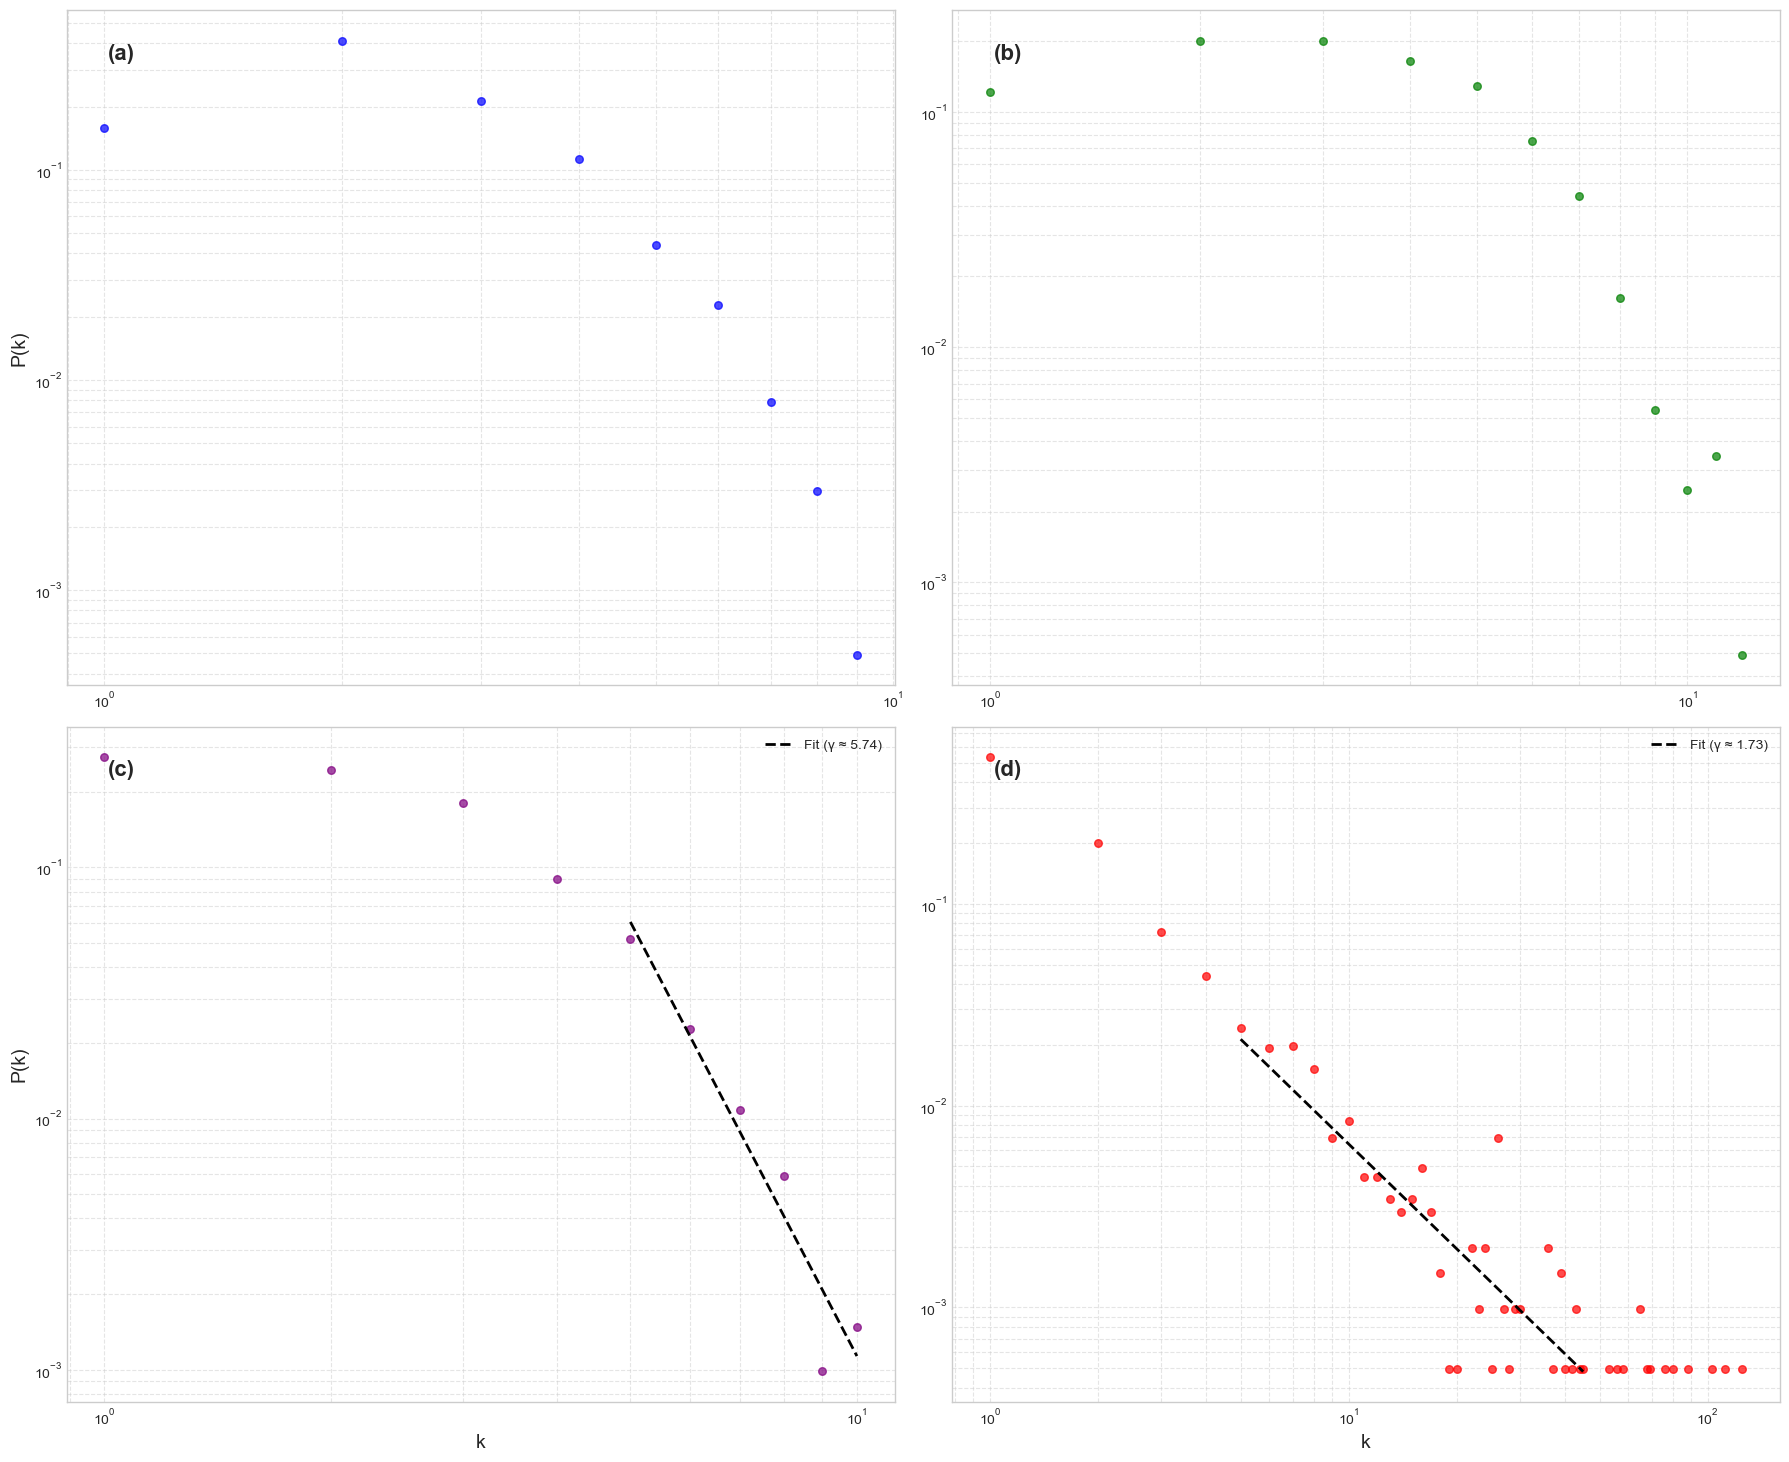

In [ ]:

path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Africa"
arquivos_de_grafos = {
    'Soares-Samurai Fotônica': os.path.join(path_base, 'soares_photonica(AF).pickle'),
    'Waxman-Samurai Fotônica': os.path.join(path_base, 'samuraí_photonica(AF).pickle'),
    'Scale-Free Fotônica': os.path.join(path_base, 'scale_free_photonica(AF).pickle'),
    'g_photonica_real': os.path.join(path_base, 'g_photon_real_AF.pickle')
}


grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado com sucesso.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo '{os.path.basename(caminho)}' não encontrado.")
        grafos_carregados[nome] = nx.Graph()


for nome, G in grafos_carregados.items():
    if G:
        print(f"- {nome}: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas.")
    else:
        print(f"- {nome}: Grafo não encontrado ou vazio.")


def plotar_pk_completo(ax, G, color, label_prefix, p_min_visual=None, k_max_visual=None, k_min_fit=None, k_max_fit=None):
    """
    Calcula e plota a Distribuição de Graus P(k) vs k.
    - p_min_visual, k_max_visual: Filtros para a visualização dos pontos.
    - k_min_fit, k_max_fit: Janela para o cálculo do expoente gamma (γ).
    """
    if not G or G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'Grafo não encontrado', ha='center', va='center', transform=ax.transAxes)
        return

    degrees = [val for (node, val) in G.degree() if val > 0]
    if not degrees:
        ax.text(0.5, 0.5, 'Rede sem arestas', ha='center', va='center', transform=ax.transAxes)
        return

    degree_counts = Counter(degrees)
    k_full = np.array(list(degree_counts.keys()))
    count_full = np.array(list(degree_counts.values()))
    sort_indices = np.argsort(k_full)
    k_full, count_full = k_full[sort_indices], count_full[sort_indices]
    pk_full = count_full / G.number_of_nodes()

    # Filtros visuais para os pontos
    indices_plot = np.full(k_full.shape, True)
    if p_min_visual is not None:
        indices_plot &= (pk_full >= p_min_visual)
    if k_max_visual is not None:
        indices_plot &= (k_full <= k_max_visual)
    k_plot, pk_plot = k_full[indices_plot], pk_full[indices_plot]

    ax.scatter(k_plot, pk_plot, color=color, alpha=0.7, s=30, label=label_prefix)

    # --- LÓGICA DE FILTRAGEM CORRIGIDA PARA O FIT ---
    # Começa por incluir todos os pontos
    indices_para_fit = np.full(k_full.shape, True)

    # Aplica o filtro k_min apenas se ele não for None
    if k_min_fit is not None:
        indices_para_fit &= (k_full >= k_min_fit)

    # Aplica o filtro k_max apenas se ele não for None
    if k_max_fit is not None:
        indices_para_fit &= (k_full <= k_max_fit)

    k_fit, pk_fit = k_full[indices_para_fit], pk_full[indices_para_fit]

    if len(k_fit) > 1:
        try:
            log_k = np.log10(k_fit)
            log_pk = np.log10(pk_fit)
            slope, intercept, _, _, _ = stats.linregress(log_k, log_pk)
            gamma = -slope # O expoente da distribuição de graus é -slope

            fit_line_data = 10**(intercept) * (k_fit**slope)

            k_max_label = '∞' if k_max_fit is None else k_max_fit
            line_label = f'Fit (γ ≈ {gamma:.2f})'

            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2, label=line_label)
        except (ValueError, IndexError):
            pass

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
axes = axes.flatten()


plots_para_fazer = {
    '''0: {'titulo': 'Modelo Soares-Samurai', 'grafo': grafos_carregados.get('Soares-Samurai Fotônica'),
        'p_min_visual': None, 'k_max_visual': None, 'k_min_fit': 0, 'k_max_fit': 1},
    1: {'titulo': 'Modelo Waxman-Samurai', 'grafo': grafos_carregados.get('Waxman-Samurai Fotônica'),
        'p_min_visual': None, 'k_max_visual': None, 'k_min_fit': 0, 'k_max_fit': 1},
    2: {'titulo': 'Modelo Scale-Free', 'grafo': grafos_carregados.get('Scale-Free Fotônica'),
        'p_min_visual': None, 'k_max_visual': None, 'k_min_fit': 5, 'k_max_fit': 10}, ''',

    3: {'titulo': 'Rede Real (NA)', 'grafo': grafos_carregados.get('g_photonica_real'),
        'p_min_visual': None, 'k_max_visual': None, 'k_min_fit': 5, 'k_max_fit': 50}
}

cores = {0: 'blue', 1: 'green', 2: 'purple', 3: 'red'}

for i, conf in plots_para_fazer.items():
    ax = axes[i]
    if conf['grafo']:
        plotar_pk_completo(ax, conf['grafo'], color=cores[i],
                           label_prefix=None,
                           p_min_visual=conf.get('p_min_visual'),
                           k_max_visual=conf.get('k_max_visual'),
                           k_min_fit=conf.get('k_min_fit', 2),
                           k_max_fit=conf.get('k_max_fit'))

   # ax.set_title(conf['titulo'], fontsize=16)

subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# Itera sobre os eixos usando enumerate para ter o índice (i) de cada gráfico
for i, ax in enumerate(axes):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.5)

    ax.text(0.05, 0.95, subplot_labels[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

    if i >= 2:
        ax.set_xlabel("k", fontsize=14)

    # Adiciona o rótulo do Eixo Y ("P(k)") apenas para os gráficos da esquerda
    # Estes correspondem aos índices i = 0 e i = 2
    if i % 2 == 0:
        ax.set_ylabel("P(k)", fontsize=14)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

*C(K) EM FUNÇÃO DOS GRAUS*

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'g_photon_real_EU.pickle' carregado.
grafos carregados: dict_items([('Rede Real', <networkx.classes.graph.Graph object at 0x7c6add31d5e0>)])

Processando rede 'None' (31430 nós)...


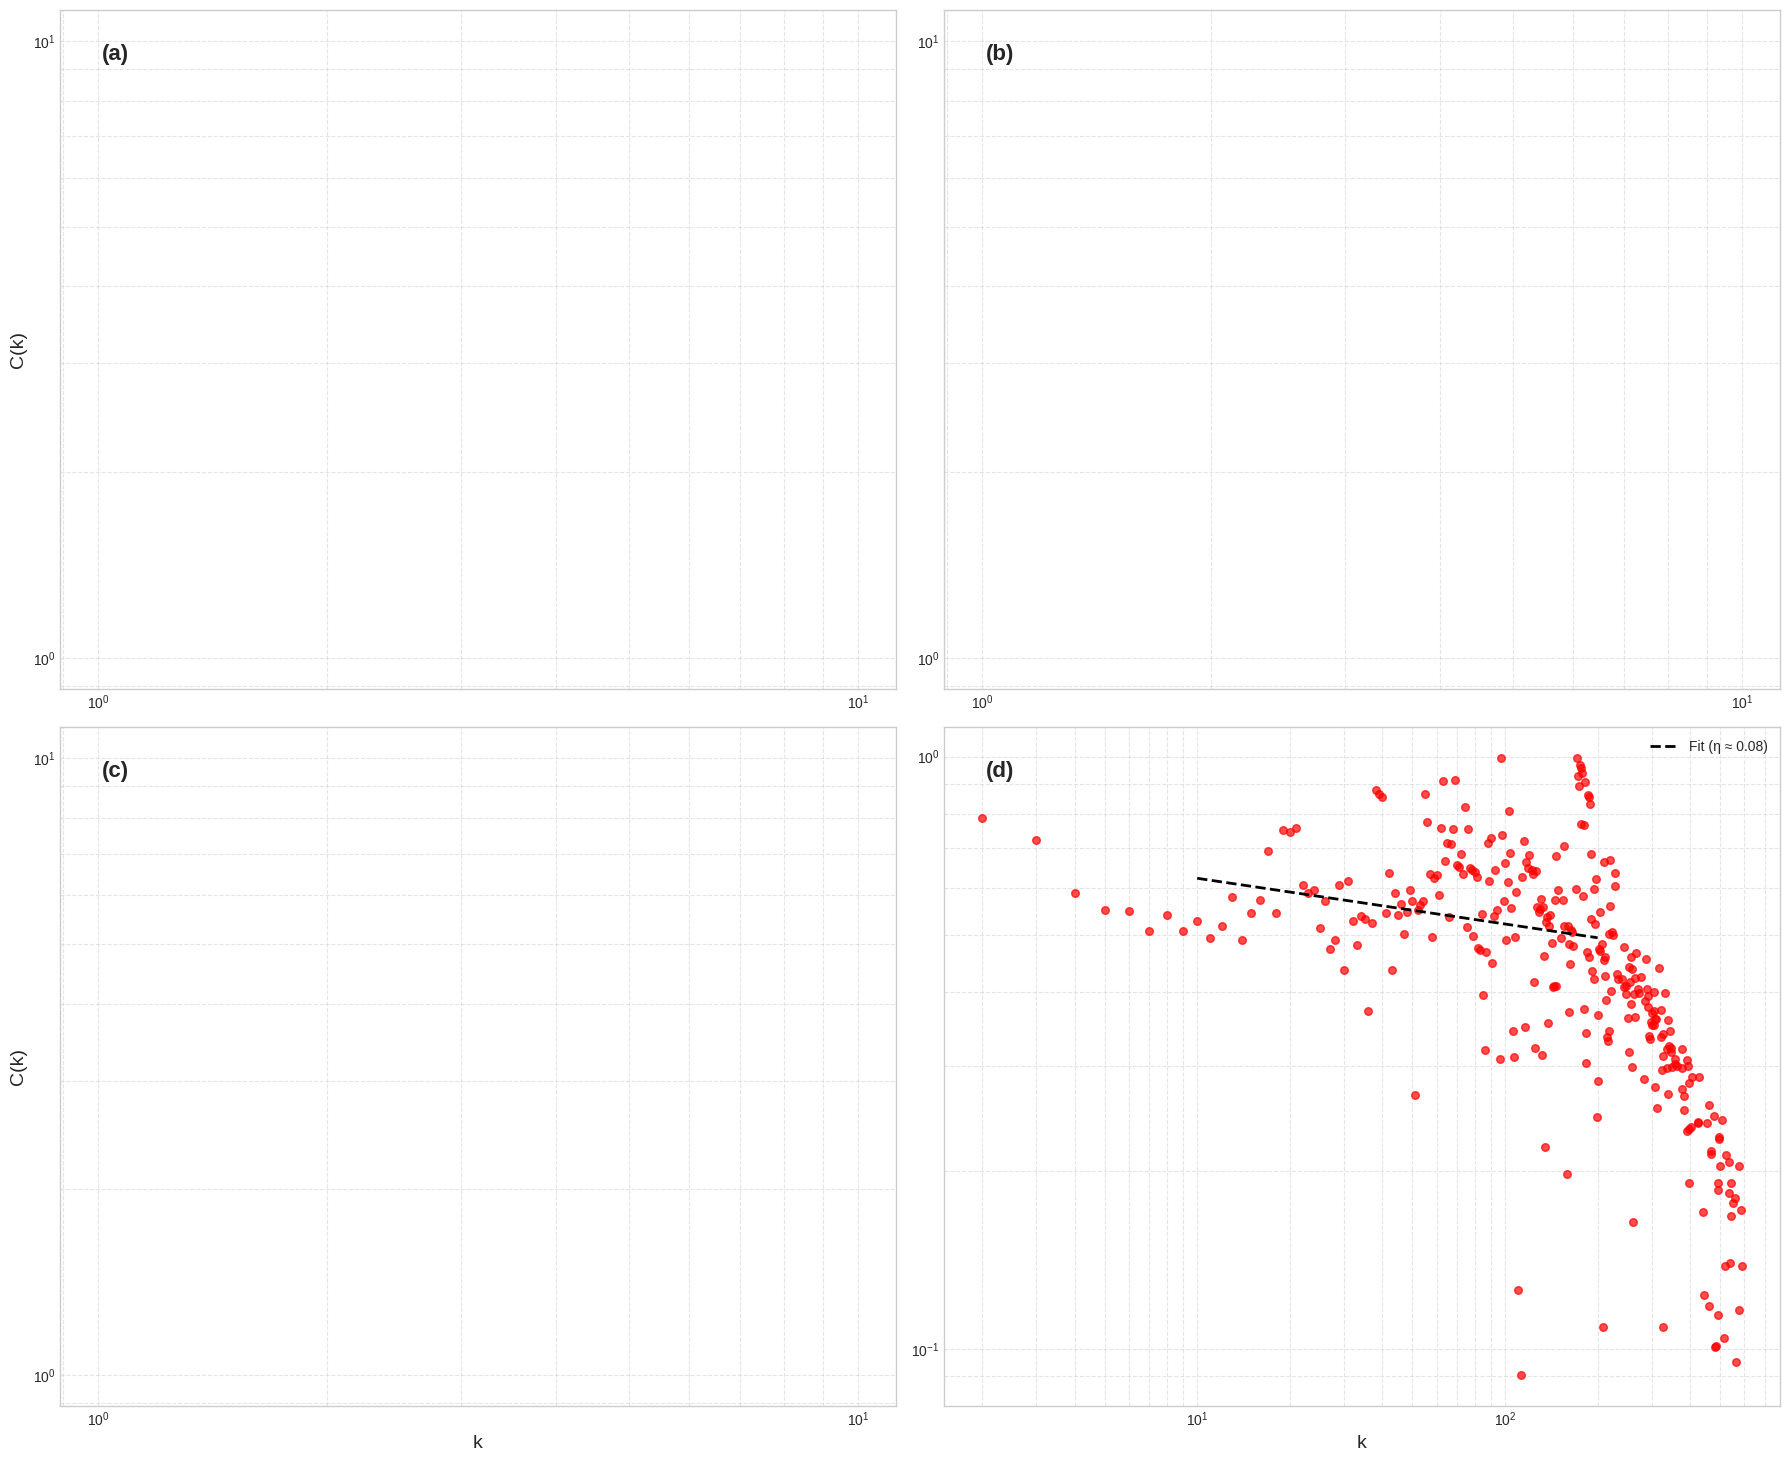

In [ ]:
path_base = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)"

# Dicionário com os nomes das redes e os caminhos para os arquivos
arquivos_de_grafos = {
    #'Soares-Samurai': os.path.join(path_base, 'soares_photonica(AF).pickle'),
    #'Waxman-Samurai': os.path.join(path_base, 'samuraí_photonica(AF).pickle'),
    #'Scale-Free': os.path.join(path_base, 'scale_free_photonica(AF).pickle'),
    'Rede Real': os.path.join(path_base, 'g_photon_real_EU.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Converte para não-direcionado para o cálculo de clusterização
            G_temp = pickle.load(f)
            if nx.is_directed(G_temp):
                grafos_carregados[nome] = G_temp.to_undirected()
            else:
                grafos_carregados[nome] = G_temp
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado.")
        grafos_carregados[nome] = None

print("grafos carregados:", grafos_carregados.items())

# --- Etapa 2: Função para Calcular e Plotar ---

def plotar_ck_completo(ax, G, color, label_prefix, c_min_visual=None,c_max_visual= None, k_max_visual=None, k_min_fit=2, k_max_fit=None):
    """
    Calcula e plota C(k) vs k, com filtros visuais e ajuste de linha
    do expoente eta (η) em uma janela.
    """
    if not G or G.number_of_nodes() == 0 or not G.edges():
        ax.text(0.5, 0.5, 'Grafo Vazio ou Inválido', ha='center', va='center', transform=ax.transAxes)
        return

    print(f"\nProcessando rede '{label_prefix}' ({G.number_of_nodes()} nós)...")

    # 1. Calcula C(k)
    graus = dict(G.degree())
    clusterizacao = nx.clustering(G)
    df_metricas = pd.DataFrame({'grau': graus, 'clusterizacao': clusterizacao})
    Ck = df_metricas.groupby('grau')['clusterizacao'].mean()
    Ck = Ck[Ck > 0]

    if Ck.empty:
        ax.text(0.5, 0.5, 'C(k)=0 para todos os nós', ha='center', va='center', transform=ax.transAxes)
        return

    k_full, Ck_full = Ck.index.to_numpy(), Ck.values

    # --- FILTROS VISUAIS (para os pontos do scatter plot) ---
    indices_plot = np.full(k_full.shape, True)
    if c_min_visual is not None:
        indices_plot &= (Ck_full >= c_min_visual)
    if c_max_visual is not None:
        indices_plot &= (Ck_full <= c_max_visual) # <-- FILTRO c_max ADICIONADO
    if k_max_visual is not None:
        indices_plot &= (k_full <= k_max_visual)

    k_plot, Ck_plot = k_full[indices_plot], Ck_full[indices_plot]

    if len(k_plot) == 0:
        ax.text(0.5, 0.5, 'Nenhum ponto\napós a filtragem', ha='center', va='center', transform=ax.transAxes)
        return

    ax.scatter(k_plot, Ck_plot, color=color, alpha=0.7, s=30, label=label_prefix)

    # --- FILTROS PARA O AJUSTE DE LINHA (Fit) ---
    indices_fit = np.where((k_full >= k_min_fit) & (k_full <= (k_max_fit or float('inf'))))
    k_fit, Ck_fit = k_full[indices_fit], Ck_full[indices_fit]

    if len(k_fit) > 1:
        try:
            log_k = np.log10(k_fit)
            log_Ck = np.log10(Ck_fit)
            slope, intercept, _, _, _ = stats.linregress(log_k, log_Ck)
            eta = -slope

            fit_line_data = 10**(intercept) * (k_fit**slope)

            k_max_label = '∞' if k_max_fit is None else k_max_fit
            line_label = f'Fit (η ≈ {eta:.2f})'

            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2, label=line_label)
        except (ValueError, IndexError):
            pass



plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
axes = axes.flatten()

# Configuração individual de cada gráfico
plots_para_fazer = {
    #0: {'titulo': 'Modelo Soares-Samurai', 'grafo': grafos_carregados.get('Soares-Samurai'),
     #   'c_min_visual': None, 'c_max_visual': None, 'k_max_visual': None, 'k_min_fit': 3, 'k_max_fit': 7},
    #1: {'titulo': 'Modelo Waxman-Samurai', 'grafo': grafos_carregados.get('Waxman-Samurai'),
     #   'c_min_visual': None, 'c_max_visual': None, 'k_max_visual': None, 'k_min_fit': 0, 'k_max_fit': 1},
    #2: {'titulo': 'Modelo Scale-Free', 'grafo': grafos_carregados.get('Scale-Free'),
     #   'c_min_visual': 0.07, 'c_max_visual': None, 'k_max_visual': None, 'k_min_fit': 2.5, 'k_max_fit': 8},

    3: {'titulo': 'Rede Real (EU)', 'grafo': grafos_carregados.get('Rede Real'),
        'c_min_visual': 0.05, 'c_max_visual': 1, 'k_max_visual': 600, 'k_min_fit': 10, 'k_max_fit': 200}
}

cores = {0: 'blue', 1: 'green', 2: 'purple', 3: 'red'}

for i, conf in plots_para_fazer.items():
    ax = axes[i]
    if conf['grafo']:
        plotar_ck_completo(ax, conf['grafo'], color=cores[i],
                           label_prefix=None,
                           c_min_visual=conf.get('c_min_visual'),
                           c_max_visual=conf.get('c_max_visual'),
                           k_max_visual=conf.get('k_max_visual'),
                           k_min_fit=conf.get('k_min_fit', 2),
                           k_max_fit=conf.get('k_max_fit'))
    #ax.set_title(conf['titulo'], fontsize=18)


subplot_labels = ['(a)', '(b)', '(c)', '(d)']

for i, ax in enumerate(axes):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Adiciona o rótulo (a), (b), etc. no canto superior esquerdo de cada gráfico
    ax.text(0.05, 0.95, subplot_labels[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

    if i >= 2:
        ax.set_xlabel("k", fontsize=14)

    if i % 2 == 0:
        ax.set_ylabel("C(k)", fontsize=14)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'g_photon_real_EU.pickle' carregado.

Processando rede 'Rede Real ' (31430 nós)...


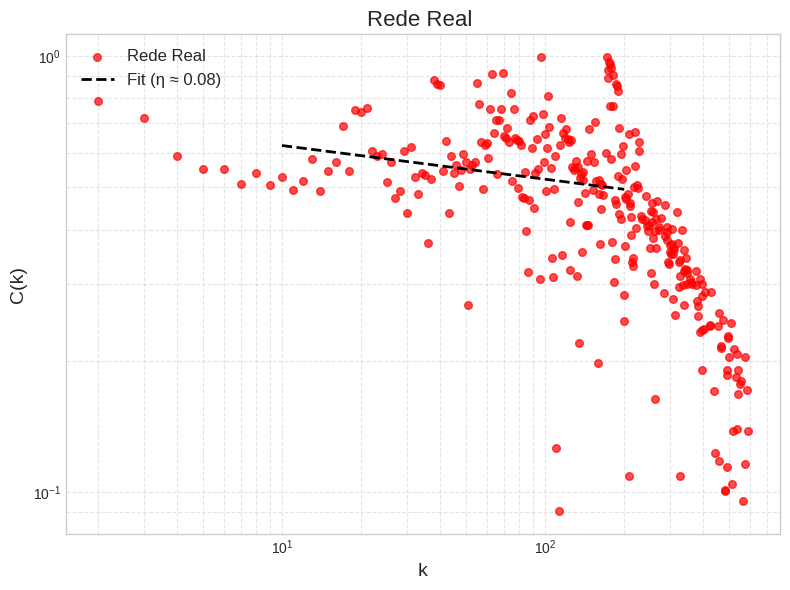

In [ ]:
path_base = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)"

# Mantemos apenas a rede real carregada
arquivos_de_grafos = {
    'Rede Real': os.path.join(path_base, 'g_photon_real_EU.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            G_temp = pickle.load(f)
            if nx.is_directed(G_temp):
                grafos_carregados[nome] = G_temp.to_undirected()
            else:
                grafos_carregados[nome] = G_temp
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado.")
        grafos_carregados[nome] = None

# --- Etapa 2: Função para Calcular e Plotar ---

def plotar_ck_completo(ax, G, color, label_prefix, c_min_visual=None, c_max_visual=None, k_max_visual=None, k_min_fit=2, k_max_fit=None):
    """
    Calcula e plota C(k) vs k, com filtros visuais e ajuste de linha
    do expoente eta (η) em uma janela.
    """
    if not G or G.number_of_nodes() == 0 or not G.edges():
        ax.text(0.5, 0.5, 'Grafo Vazio ou Inválido', ha='center', va='center', transform=ax.transAxes)
        return

    print(f"\nProcessando rede '{label_prefix}' ({G.number_of_nodes()} nós)...")

    # 1. Calcula C(k)
    graus = dict(G.degree())
    clusterizacao = nx.clustering(G)
    df_metricas = pd.DataFrame({'grau': graus, 'clusterizacao': clusterizacao})
    Ck = df_metricas.groupby('grau')['clusterizacao'].mean()
    Ck = Ck[Ck > 0]

    if Ck.empty:
        ax.text(0.5, 0.5, 'C(k)=0 para todos os nós', ha='center', va='center', transform=ax.transAxes)
        return

    k_full, Ck_full = Ck.index.to_numpy(), Ck.values

    # --- FILTROS VISUAIS (para os pontos do scatter plot) ---
    indices_plot = np.full(k_full.shape, True)
    if c_min_visual is not None:
        indices_plot &= (Ck_full >= c_min_visual)
    if c_max_visual is not None:
        indices_plot &= (Ck_full <= c_max_visual)
    if k_max_visual is not None:
        indices_plot &= (k_full <= k_max_visual)

    k_plot, Ck_plot = k_full[indices_plot], Ck_full[indices_plot]

    if len(k_plot) == 0:
        ax.text(0.5, 0.5, 'Nenhum ponto\napós a filtragem', ha='center', va='center', transform=ax.transAxes)
        return

    # Usamos label_prefix como a string da legenda caso ele não seja None
    label_str = label_prefix if label_prefix else "Dados"
    ax.scatter(k_plot, Ck_plot, color=color, alpha=0.7, s=30, label=label_str)

    # --- FILTROS PARA O AJUSTE DE LINHA (Fit) ---
    indices_fit = np.where((k_full >= k_min_fit) & (k_full <= (k_max_fit or float('inf'))))
    k_fit, Ck_fit = k_full[indices_fit], Ck_full[indices_fit]

    if len(k_fit) > 1:
        try:
            log_k = np.log10(k_fit)
            log_Ck = np.log10(Ck_fit)
            slope, intercept, _, _, _ = stats.linregress(log_k, log_Ck)
            eta = -slope

            fit_line_data = 10**(intercept) * (k_fit**slope)
            line_label = f'Fit (η ≈ {eta:.2f})'

            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2, label=line_label)
        except (ValueError, IndexError):
            pass

# --- Etapa 3: Plotagem (Apenas 1 Subplot) ---

plt.style.use('seaborn-v0_8-whitegrid')

# Alterado de (2, 2) para apenas 1 eixo (1, 1).
# Reduzimos o figsize pois não precisamos mais do quadro 18x16 gigante.
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

# Configuração da Rede Real
conf = {
    'titulo': 'Rede Real ', 'grafo': grafos_carregados.get('Rede Real'),
    'c_min_visual': 0.05, 'c_max_visual': 1, 'k_max_visual': 600, 'k_min_fit': 10, 'k_max_fit': 200
}

if conf['grafo']:
    plotar_ck_completo(ax, conf['grafo'], color='red',
                       label_prefix=conf['titulo'],
                       c_min_visual=conf.get('c_min_visual'),
                       c_max_visual=conf.get('c_max_visual'),
                       k_max_visual=conf.get('k_max_visual'),
                       k_min_fit=conf.get('k_min_fit', 2),
                       k_max_fit=conf.get('k_max_fit'))

# Formatação do único eixo
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which="both", ls="--", alpha=0.5)

ax.set_xlabel("k", fontsize=14)
ax.set_ylabel("C(k)", fontsize=14)
ax.set_title(conf['titulo'], fontsize=16)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("C(k)vsK.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

*K_N_N*

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'g_photon_real_EU.pickle' carregado.

--- Gerando os gráficos k_nn(k) vs k para cada rede ---

--- Gerando os gráficos k_nn(k) vs k com filtro de ruído ---


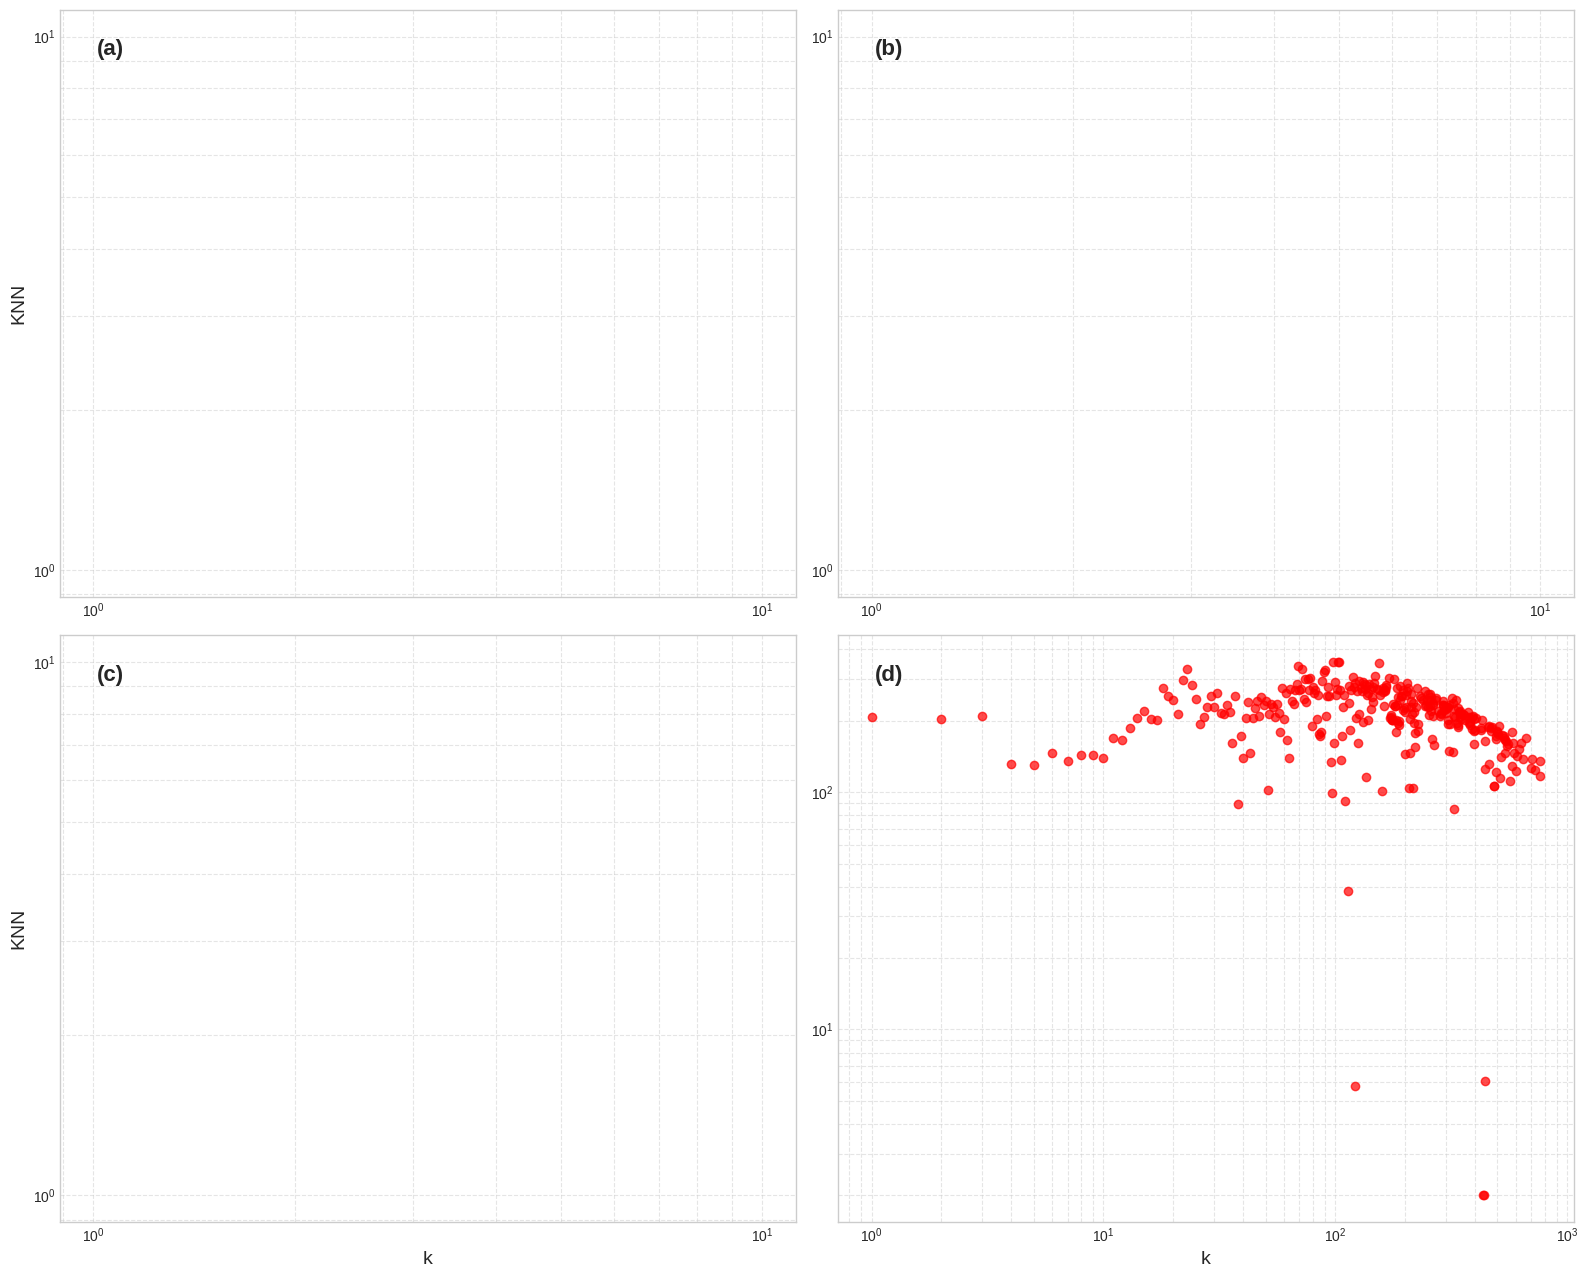

In [ ]:
path_base = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)"

# Dicionário com os nomes das redes e os caminhos para os arquivos
arquivos_de_grafos = {
    #'Soares-Samurai': os.path.join(path_base, 'soares_photonica(AF).pickle'),
    #'Waxman-Samurai': os.path.join(path_base, 'samuraí_photonica(AF).pickle'),
    #'Scale-Free': os.path.join(path_base, 'scale_free_photonica(AF).pickle'),
    'Rede Real': os.path.join(path_base, 'g_photon_real_EU.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Converte para não-direcionado, pois a assortatividade é mais comum em grafos não-direcionados
            G_temp = pickle.load(f)
            if nx.is_directed(G_temp):
                grafos_carregados[nome] = G_temp.to_undirected()
            else:
                grafos_carregados[nome] = G_temp
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado.")
        grafos_carregados[nome] = None



print("\n--- Gerando os gráficos k_nn(k) vs k para cada rede ---")

def plotar_knn_completo(ax, G, color, label_prefix, y_min_visual=None,y_max_visual=None, k_max_visual=None, k_min_fit=2, k_max_fit=None):
    """
    Calcula e plota k_nn(k) vs k, com filtros visuais e ajuste de linha
    do expoente alpha (α) em uma janela.
    """
    if not G or G.number_of_nodes() == 0 or not G.edges():
        ax.text(0.5, 0.5, 'Dados não encontrados', ha='center', va='center', transform=ax.transAxes)
        return

    knn = nx.average_degree_connectivity(G)
    if not knn: return

    k_full = np.array(sorted(knn.keys()))
    knn_full = np.array([knn[k] for k in k_full])

    # --- FILTROS VISUAIS (para os pontos do scatter plot) ---
    indices_plot = np.full(k_full.shape, True)
    if y_min_visual is not None:
        indices_plot &= (knn_full >= y_min_visual)
    if y_max_visual is not None:
        indices_plot &= (knn_full <= y_max_visual) # <-- FILTRO y_max ADICIONADO
    if k_max_visual is not None:
        indices_plot &= (k_full <= k_max_visual)

    k_plot, knn_plot = k_full[indices_plot], knn_full[indices_plot]

    if len(k_plot) == 0:
        ax.text(0.5, 0.5, 'Nenhum ponto\napós a filtragem', ha='center', va='center', transform=ax.transAxes)
        return

    ax.loglog(k_plot, knn_plot, marker='o', linestyle='None', color=color, alpha=0.7, label=label_prefix)

    # --- FILTROS PARA O AJUSTE DE LINHA (Fit) ---
    indices_fit = np.where((k_full >= k_min_fit) & (k_full <= (k_max_fit or float('inf'))))
    k_fit, knn_fit = k_full[indices_fit], knn_full[indices_fit]

    if len(k_fit) > 1:
        try:
            log_k = np.log10(k_fit)
            log_knn = np.log10(knn_fit)
            slope, intercept, _, _, _ = stats.linregress(log_k, log_knn)
            alpha = slope
            fit_line_data = 10**(intercept) * (k_fit**slope)
            k_max_label = '∞' if k_max_fit is None else k_max_fit
            line_label = f'Fit (α ≈ {alpha:.2f})\nk ∈ [{k_min_fit}, {k_max_label}]'
            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2, label=None)
        except (ValueError, IndexError):
            pass



print("\n--- Gerando os gráficos k_nn(k) vs k com filtro de ruído ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='white')
axes = axes.flatten()


plots_para_fazer = {
    #0: {'titulo': 'Modelo Soares-Samurai', 'grafo': grafos_carregados.get('Soares-Samurai'),
    #    'y_min_visual': None, 'y_max_visual': None, 'k_max_visual': None, 'k_min_fit': 0, 'k_max_fit': 1},
    #1: {'titulo': 'Modelo Waxman-Samurai', 'grafo': grafos_carregados.get('Waxman-Samurai'),
     #   'y_min_visual': None, 'y_max_visual': None, 'k_max_visual': None, 'k_min_fit': 0, 'k_max_fit': 1},
    #2: {'titulo': 'Modelo Scale-Free', 'grafo': grafos_carregados.get('Scale-Free'),
     #   'y_min_visual': None, 'y_max_visual': None, 'k_max_visual': None, 'k_min_fit': 0, 'k_max_fit': 1},
    3: {'titulo': 'Rede Real (NA) - Filtrada', 'grafo': grafos_carregados.get('Rede Real'),
        'y_min_visual': 2, 'y_max_visual': None, 'k_max_visual': 800, 'k_min_fit': 0, 'k_max_fit': 1}
}

cores = {0: 'blue', 1: 'green', 2: 'purple', 3: 'red'}

for i, conf in plots_para_fazer.items():
    ax = axes[i]
    if conf['grafo']:
        plotar_knn_completo(ax, conf['grafo'], color=cores.get(i),
                            label_prefix=None,
                            y_min_visual=conf.get('y_min_visual'),
                            y_max_visual=conf.get('y_max_visual'),
                            k_max_visual=conf.get('k_max_visual'),
                            k_min_fit=conf.get('k_min_fit', 2),
                            k_max_fit=conf.get('k_max_fit'))

subplot_labels = ['(a)', '(b)', '(c)', '(d)']

for i, ax in enumerate(axes):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Adiciona o rótulo (a), (b), etc. no canto superior esquerdo de cada gráfico
    ax.text(0.05, 0.95, subplot_labels[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

    if i >= 2:
        ax.set_xlabel("k", fontsize=14)

    if i % 2 == 0:
        ax.set_ylabel("KNN", fontsize=14)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'g_photon_real_EU.pickle' carregado.

--- Gerando o gráfico k_nn(k) vs k ---


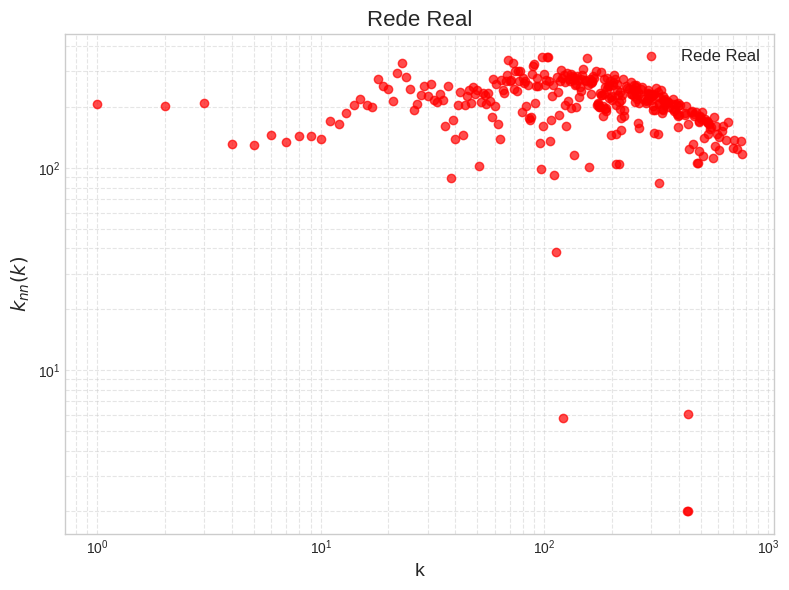

In [7]:
path_base = r"/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)"

# Dicionário mantendo apenas a Rede Real
arquivos_de_grafos = {
    'Rede Real': os.path.join(path_base, 'g_photon_real_EU.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Converte para não-direcionado para o cálculo de assortatividade
            G_temp = pickle.load(f)
            if nx.is_directed(G_temp):
                grafos_carregados[nome] = G_temp.to_undirected()
            else:
                grafos_carregados[nome] = G_temp
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado.")
        grafos_carregados[nome] = None

print("\n--- Gerando o gráfico k_nn(k) vs k ---")

def plotar_knn_completo(ax, G, color, label_prefix, y_min_visual=None, y_max_visual=None, k_max_visual=None, k_min_fit=2, k_max_fit=None):
    """
    Calcula e plota k_nn(k) vs k, com filtros visuais e ajuste de linha
    do expoente alpha (α) em uma janela.
    """
    if not G or G.number_of_nodes() == 0 or not G.edges():
        ax.text(0.5, 0.5, 'Dados não encontrados', ha='center', va='center', transform=ax.transAxes)
        return

    knn = nx.average_degree_connectivity(G)
    if not knn: return

    k_full = np.array(sorted(knn.keys()))
    knn_full = np.array([knn[k] for k in k_full])

    # --- FILTROS VISUAIS (para os pontos do scatter plot) ---
    indices_plot = np.full(k_full.shape, True)
    if y_min_visual is not None:
        indices_plot &= (knn_full >= y_min_visual)
    if y_max_visual is not None:
        indices_plot &= (knn_full <= y_max_visual)
    if k_max_visual is not None:
        indices_plot &= (k_full <= k_max_visual)

    k_plot, knn_plot = k_full[indices_plot], knn_full[indices_plot]

    if len(k_plot) == 0:
        ax.text(0.5, 0.5, 'Nenhum ponto\napós a filtragem', ha='center', va='center', transform=ax.transAxes)
        return

    # Passa o nome da rede para a legenda
    ax.loglog(k_plot, knn_plot, marker='o', linestyle='None', color=color, alpha=0.7, label=label_prefix)

    # --- FILTROS PARA O AJUSTE DE LINHA (Fit) ---
    indices_fit = np.where((k_full >= k_min_fit) & (k_full <= (k_max_fit or float('inf'))))
    k_fit, knn_fit = k_full[indices_fit], knn_full[indices_fit]

    if len(k_fit) > 1:
        try:
            log_k = np.log10(k_fit)
            log_knn = np.log10(knn_fit)
            slope, intercept, _, _, _ = stats.linregress(log_k, log_knn)
            alpha = slope
            fit_line_data = 10**(intercept) * (k_fit**slope)
            k_max_label = '∞' if k_max_fit is None else k_max_fit
            line_label = f'Fit (α ≈ {alpha:.2f})\nk ∈ [{k_min_fit}, {k_max_label}]'

            # CORREÇÃO: Alterado de label=None para label=line_label para exibir o Fit na legenda
            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2, label=line_label)
        except (ValueError, IndexError):
            pass


# --- Etapa 3: Plotagem (Apenas 1 Subplot) ---
plt.style.use('seaborn-v0_8-whitegrid')

# Criando apenas uma figura e um eixo
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

# Configuração específica para a Rede Real
conf = {
    'titulo': 'Rede Real',
    'grafo': grafos_carregados.get('Rede Real'),
    'y_min_visual': 2,
    'y_max_visual': None,
    'k_max_visual': 800,
    'k_min_fit': 0,
    'k_max_fit': 1
}

if conf['grafo']:
    plotar_knn_completo(ax, conf['grafo'], color='red',
                        label_prefix=conf['titulo'],
                        y_min_visual=conf.get('y_min_visual'),
                        y_max_visual=conf.get('y_max_visual'),
                        k_max_visual=conf.get('k_max_visual'),
                        k_min_fit=conf.get('k_min_fit', 2),
                        k_max_fit=conf.get('k_max_fit'))

# Formatação do único eixo
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which="both", ls="--", alpha=0.5)

ax.set_xlabel("k", fontsize=14)
ax.set_ylabel("$k_{nn}(k)$", fontsize=14) # Usando formatação LaTeX para o eixo Y
ax.set_title(conf['titulo'], fontsize=16)

# Configuração da Legenda
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("Knn(k)vsK.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()

Plotagem dos nós geolocalizados

Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Oceania\g_fiber_real_OC.pickle' carregado com sucesso.
Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Oceania\g_photon_real_OC.pickle' carregado com sucesso.
n° de arestas(fibra):'23786'
n° de (photonica): '22636'
-> Desenhando os nós...


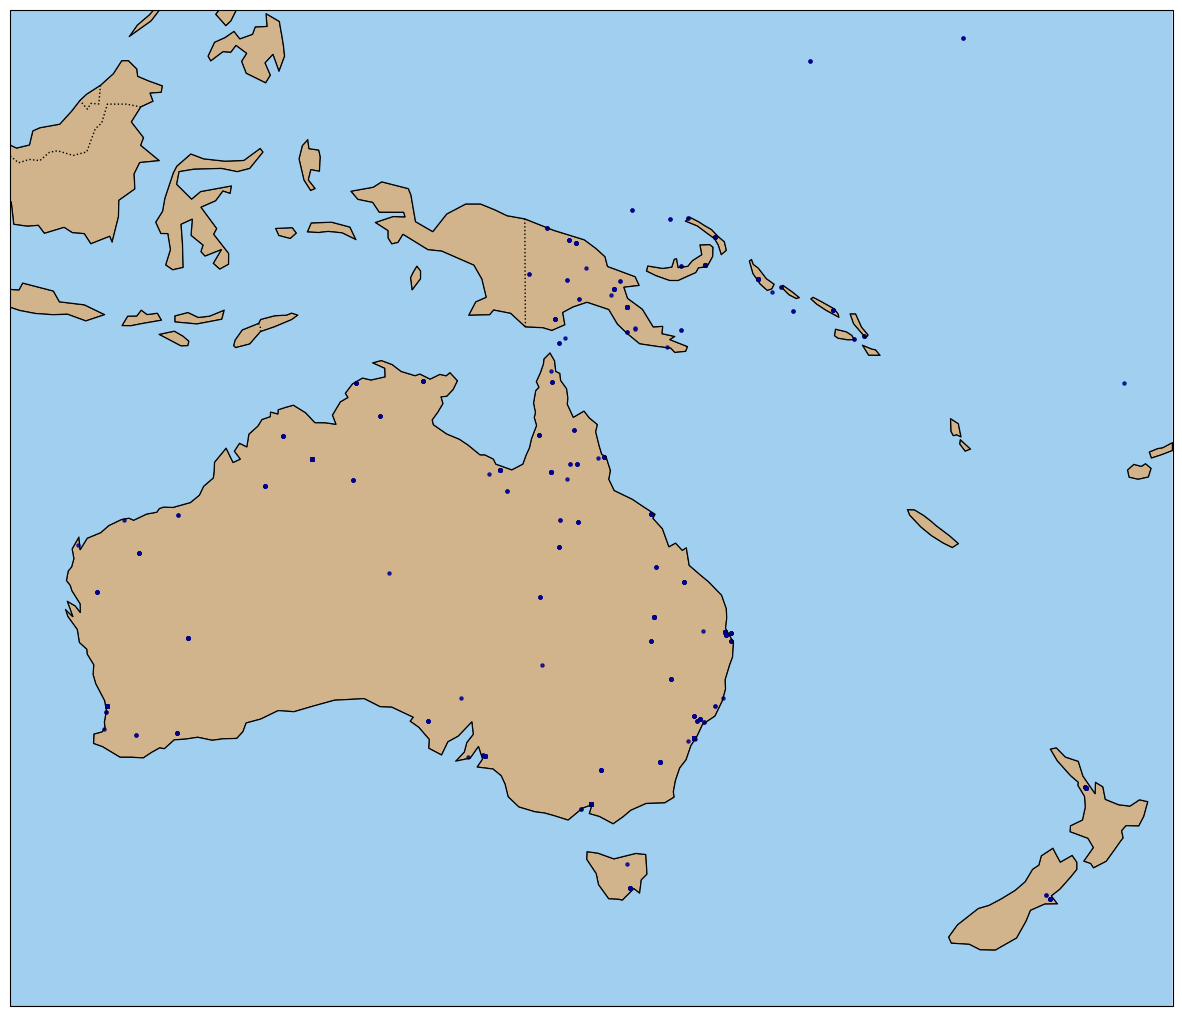

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Oceania"

# Dicionário com os nomes das redes e os caminhos para os arquivos
path_fibra =  os.path.join(path_base, 'g_fiber_real_OC.pickle')
path_photonica  = os.path.join(path_base,'g_photon_real_OC.pickle')


try:
    with open(path_fibra, 'rb') as f:
        G_fibra = pickle.load(f)
    print(f"Arquivo '{path_fibra}' carregado com sucesso.")

    with open(path_photonica, 'rb') as f:
        G_photonica = pickle.load(f)
    print(f"Arquivo '{path_photonica}' carregado com sucesso.")

except FileNotFoundError as e:
    print(f" arquivo não encontrado: {e}")

print(f"n° de arestas(fibra):'{G_fibra.number_of_edges()}'")
print(f"n° de (photonica): '{G_photonica.number_of_edges()}'")

if G_fibra and G_photonica:
    pos = nx.get_node_attributes(G_fibra, 'pos')

    if not pos:
        print("ERRO: O grafo de fibra não possui o atributo 'pos' com as coordenadas.")
    else:

        fig = plt.figure(figsize=(15, 15))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Foco na Oceania
        ax.set_extent([110, 180, -50, 10], crs=ccrs.PlateCarree())

        # Adiciona elementos visuais ao mapa
        ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='#d2b48c')
        ax.add_feature(cfeature.OCEAN, facecolor='#a0cff0')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        #ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

        # --- Camada 1: Desenhar as Arestas da Rede de Fibra (cinza) ---
        '''
        print("-> Desenhando a rede de fibra (infraestrutura)...")
        for u, v in G_fibra.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='black', linewidth=0.8, alpha=0.7,
                        transform=ccrs.Geodetic())

        # --- Camada 2: Desenhar as Arestas da Rede Fotônica (vermelho) ---
        print("-> Desenhando a rede fotônica (links ativos)...")
        for u, v in G_photonica.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='red', linewidth=0.8, alpha=0.8,
                        transform=ccrs.Geodetic())
'''
        # --- Camada 3: Desenhar os Nós ---
        print("-> Desenhando os nós...")
        lons = [pos[node][0] for node in G_fibra.nodes() if node in pos]
        lats = [pos[node][1] for node in G_fibra.nodes() if node in pos]

        ax.scatter(lons, lats,
                   s=5, color='darkblue', alpha=0.8,
                   transform=ccrs.PlateCarree())

        # --- Criar a Legenda ---
        legend_elements = [
            Line2D([0], [0], color='gray', lw=0.5, label=None),
            Line2D([0], [0], color='red', lw=1, label=None),
            Line2D([0], [0], marker='o', color='w', label=None,
                   markerfacecolor='darkblue', markersize=5)
        ]
        #ax.legend(handles=legend_elements, loc='best', fontsize=12)

        #plt.title("Rede Fotônica sobre a Infraestrutura de Fibra (América do Norte)", fontsize=16)
        plt.show()





Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Asia\g_fiber_real_AS.pickle' carregado com sucesso.
Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Asia\g_photon_real_AS.pickle' carregado com sucesso.
n° de arestas(fibra):'43429'
n° de (photonica): '41350'
21317
-> Desenhando os nós...


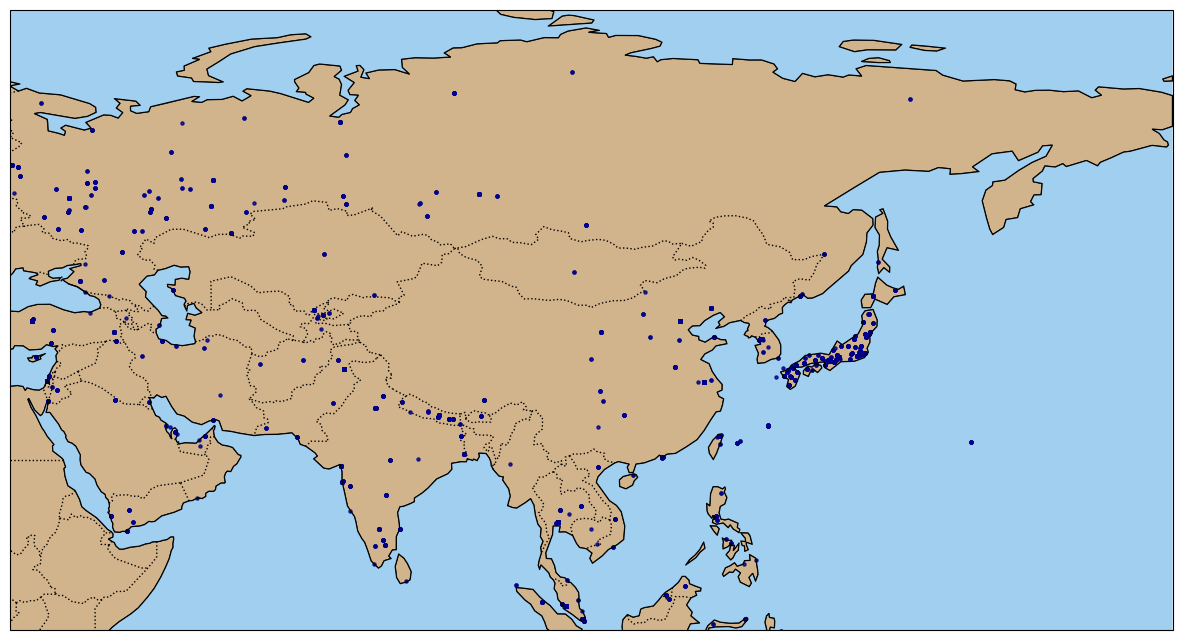

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Asia"

# Dicionário com os nomes das redes e os caminhos para os arquivos
path_fibra =  os.path.join(path_base, 'g_fiber_real_AS.pickle')
path_photonica  = os.path.join(path_base,'g_photon_real_AS.pickle')


try:
    with open(path_fibra, 'rb') as f:
        G_fibra = pickle.load(f)
    print(f"Arquivo '{path_fibra}' carregado com sucesso.")

    with open(path_photonica, 'rb') as f:
        G_photonica = pickle.load(f)
    print(f"Arquivo '{path_photonica}' carregado com sucesso.")

except FileNotFoundError as e:
    print(f" arquivo não encontrado: {e}")

print(f"n° de arestas(fibra):'{G_fibra.number_of_edges()}'")
print(f"n° de (photonica): '{G_photonica.number_of_edges()}'")
print(G_photonica.number_of_nodes())

if G_fibra and G_photonica:
    pos = nx.get_node_attributes(G_fibra, 'pos')

    if not pos:
        print("ERRO: O grafo de fibra não possui o atributo 'pos' com as coordenadas.")
    else:

        fig = plt.figure(figsize=(15, 15))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Asia
        ax.set_extent([30, 180, 0, 80], crs=ccrs.PlateCarree())

        # Adiciona elementos visuais ao mapa
        ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='#d2b48c')
        ax.add_feature(cfeature.OCEAN, facecolor='#a0cff0')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        #ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

        # --- Camada 1: Desenhar as Arestas da Rede de Fibra (cinza) ---
        '''
        print("-> Desenhando a rede de fibra (infraestrutura)...")
        for u, v in G_fibra.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='black', linewidth=0.3, alpha=0.5,
                        transform=ccrs.Geodetic())

        # --- Camada 2: Desenhar as Arestas da Rede Fotônica (vermelho) ---
        print("-> Desenhando a rede fotônica (links ativos)...")
        for u, v in G_photonica.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='red', linewidth=0.5, alpha=0.6,
                        transform=ccrs.Geodetic())
'''
        # --- Camada 3: Desenhar os Nós ---
        print("-> Desenhando os nós...")
        lons = [pos[node][0] for node in G_fibra.nodes() if node in pos]
        lats = [pos[node][1] for node in G_fibra.nodes() if node in pos]

        ax.scatter(lons, lats,
                   s=5, color='darkblue', alpha=0.8,
                   transform=ccrs.PlateCarree())

        # --- Criar a Legenda ---
        legend_elements = [
            Line2D([0], [0], color='gray', lw=0.5, label=None),
            Line2D([0], [0], color='red', lw=1, label=None),
            Line2D([0], [0], marker='o', color='w', label=None,
                   markerfacecolor='darkblue', markersize=5)
        ]
        #ax.legend(handles=legend_elements, loc='best', fontsize=12)

        #plt.title("Rede Fotônica sobre a Infraestrutura de Fibra (América do Norte)", fontsize=16)
        plt.show()





Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\America do Norte\g_fiber_real_NA.pickle' carregado com sucesso.
Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\America do Norte\g_photon_real_NA.pickle' carregado com sucesso.
n° de arestas(fibra):'147145'
n° de (photonica): '129548'
-> Desenhando os nós...


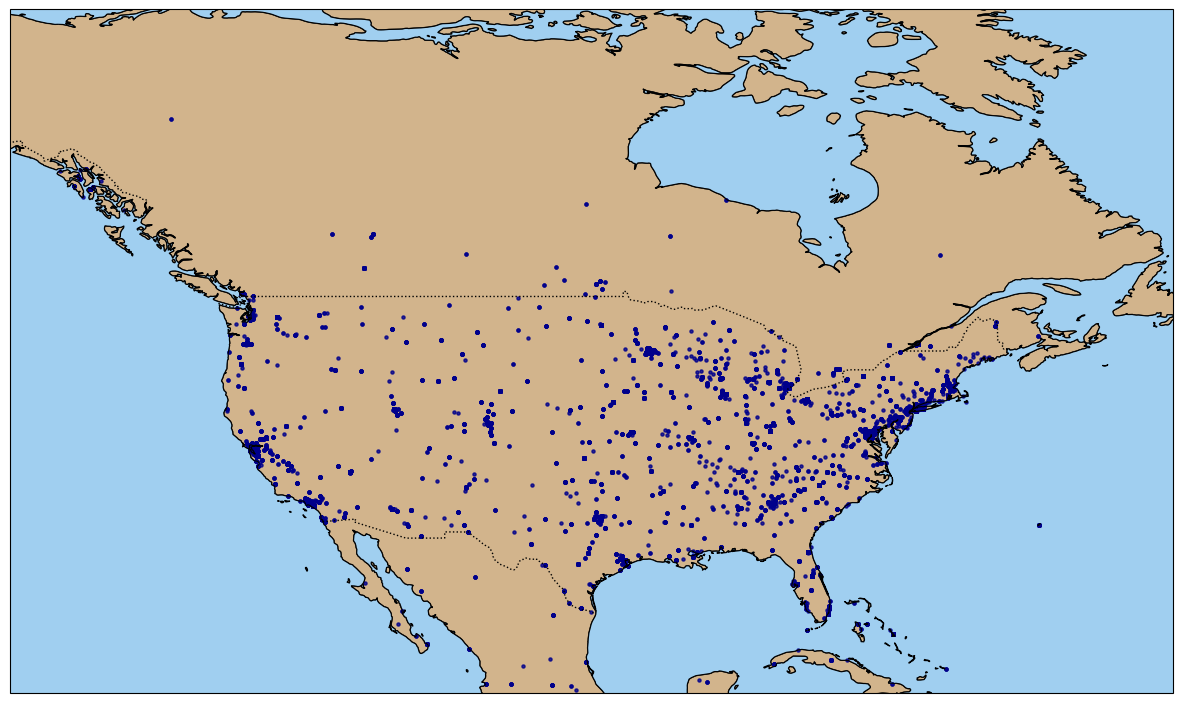

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\America do Norte"

# Dicionário com os nomes das redes e os caminhos para os arquivos
path_fibra =  os.path.join(path_base, 'g_fiber_real_NA.pickle')
path_photonica  = os.path.join(path_base,'g_photon_real_NA.pickle')


try:
    with open(path_fibra, 'rb') as f:
        G_fibra = pickle.load(f)
    print(f"Arquivo '{path_fibra}' carregado com sucesso.")

    with open(path_photonica, 'rb') as f:
        G_photonica = pickle.load(f)
    print(f"Arquivo '{path_photonica}' carregado com sucesso.")

except FileNotFoundError as e:
    print(f" arquivo não encontrado: {e}")

print(f"n° de arestas(fibra):'{G_fibra.number_of_edges()}'")
print(f"n° de (photonica): '{G_photonica.number_of_edges()}'")

if G_fibra and G_photonica:
    pos = nx.get_node_attributes(G_fibra, 'pos')

    if not pos:
        print("ERRO: O grafo de fibra não possui o atributo 'pos' com as coordenadas.")
    else:

        fig = plt.figure(figsize=(15, 15))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Asia
        ax.set_extent([-140, -55, 20, 70], crs=ccrs.PlateCarree())

        # Adiciona elementos visuais ao mapa
        ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='#d2b48c')
        ax.add_feature(cfeature.OCEAN, facecolor='#a0cff0')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        #ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

        # --- Camada 1: Desenhar as Arestas da Rede de Fibra (cinza) ---
        '''
        print("-> Desenhando a rede de fibra (infraestrutura)...")
        for u, v in G_fibra.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='black', linewidth=0.3, alpha=0.4,
                        transform=ccrs.Geodetic())

        # --- Camada 2: Desenhar as Arestas da Rede Fotônica (vermelho) ---
        print("-> Desenhando a rede fotônica (links ativos)...")
        for u, v in G_photonica.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='red', linewidth=0.4, alpha=0.6,
                        transform=ccrs.Geodetic())
'''
        # --- Camada 3: Desenhar os Nós ---
        print("-> Desenhando os nós...")
        lons = [pos[node][0] for node in G_fibra.nodes() if node in pos]
        lats = [pos[node][1] for node in G_fibra.nodes() if node in pos]

        ax.scatter(lons, lats,
                   s=5, color='darkblue', alpha=0.8,
                   transform=ccrs.PlateCarree())

        # --- Criar a Legenda ---
        legend_elements = [
            Line2D([0], [0], color='gray', lw=0.5, label=None),
            Line2D([0], [0], color='red', lw=1, label=None),
            Line2D([0], [0], marker='o', color='w', label=None,
                   markerfacecolor='darkblue', markersize=5)
        ]
        #ax.legend(handles=legend_elements, loc='best', fontsize=12)

        #plt.title("Rede Fotônica sobre a Infraestrutura de Fibra (América do Norte)", fontsize=16)
        plt.show()





Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Europa\g_fiber_real_EU.pickle' carregado com sucesso.
Arquivo 'C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Europa\g_photon_real_EU.pickle' carregado com sucesso.
n° de arestas(fibra):'141533'
n° de (photonica): '125327'
-> Desenhando os nós...


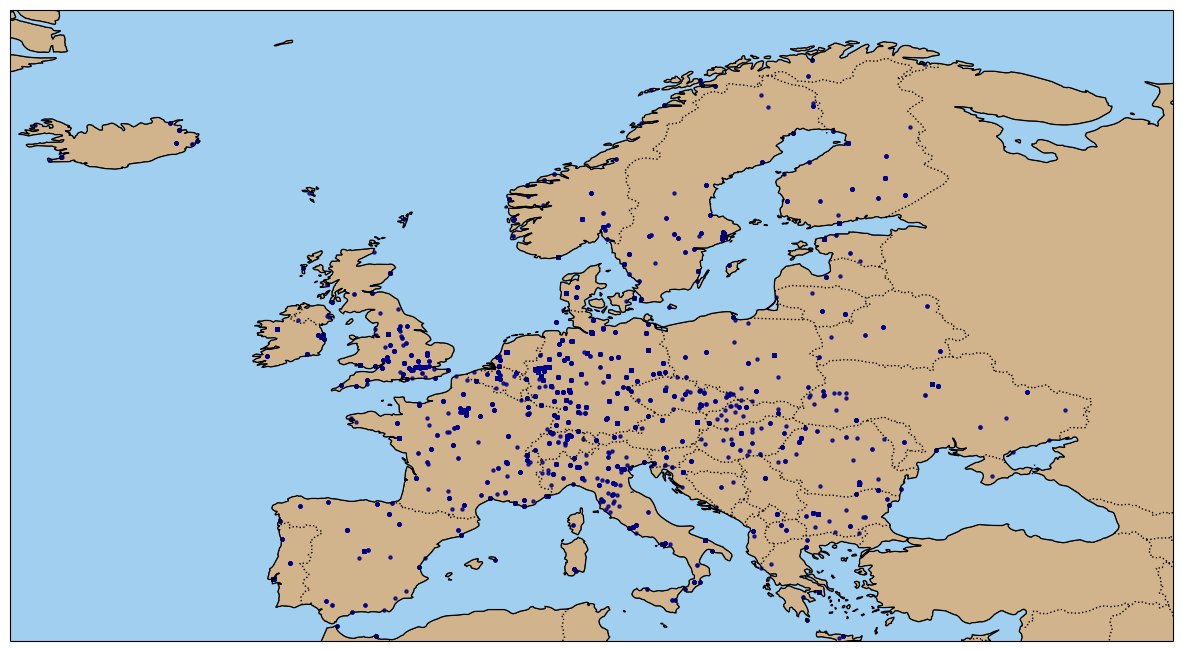

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Europa"

# Dicionário com os nomes das redes e os caminhos para os arquivos
path_fibra =  os.path.join(path_base, 'g_fiber_real_EU.pickle')
path_photonica  = os.path.join(path_base,'g_photon_real_EU.pickle')


try:
    with open(path_fibra, 'rb') as f:
        G_fibra = pickle.load(f)
    print(f"Arquivo '{path_fibra}' carregado com sucesso.")

    with open(path_photonica, 'rb') as f:
        G_photonica = pickle.load(f)
    print(f"Arquivo '{path_photonica}' carregado com sucesso.")

except FileNotFoundError as e:
    print(f" arquivo não encontrado: {e}")

print(f"n° de arestas(fibra):'{G_fibra.number_of_edges()}'")
print(f"n° de (photonica): '{G_photonica.number_of_edges()}'")

if G_fibra and G_photonica:
    pos = nx.get_node_attributes(G_fibra, 'pos')

    if not pos:
        print("ERRO: O grafo de fibra não possui o atributo 'pos' com as coordenadas.")
    else:

        fig = plt.figure(figsize=(15, 15))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Asia
        ax.set_extent([-25, 45, 35, 73], crs=ccrs.PlateCarree())

        # Adiciona elementos visuais ao mapa
        ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='#d2b48c')
        ax.add_feature(cfeature.OCEAN, facecolor='#a0cff0')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        #ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

        # --- Camada 1: Desenhar as Arestas da Rede de Fibra (cinza) ---
        '''
        print("-> Desenhando a rede de fibra (infraestrutura)...")
        for u, v in G_fibra.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='black', linewidth=0.3, alpha=0.4,
                        transform=ccrs.Geodetic())

        # --- Camada 2: Desenhar as Arestas da Rede Fotônica (vermelho) ---
        print("-> Desenhando a rede fotônica (links ativos)...")
        for u, v in G_photonica.edges():
            if u in pos and v in pos:
                lon1, lat1 = pos[u]
                lon2, lat2 = pos[v]
                ax.plot([lon1, lon2], [lat1, lat2],
                        color='red', linewidth=0.4, alpha=0.6,
                        transform=ccrs.Geodetic())
'''
        # --- Camada 3: Desenhar os Nós ---
        print("Desenhando os nós")
        lons = [pos[node][0] for node in G_fibra.nodes() if node in pos]
        lats = [pos[node][1] for node in G_fibra.nodes() if node in pos]

        ax.scatter(lons, lats,
                   s=5, color='darkblue', alpha=0.8,
                   transform=ccrs.PlateCarree())

        # --- Criar a Legenda ---
        legend_elements = [
            Line2D([0], [0], color='gray', lw=0.5, label=None),
            Line2D([0], [0], color='red', lw=1, label=None),
            Line2D([0], [0], marker='o', color='w', label=None,
                   markerfacecolor='darkblue', markersize=5)
        ]
        #ax.legend(handles=legend_elements, loc='best', fontsize=12)

        #plt.title("Rede Fotônica sobre a Infraestrutura de Fibra (América do Norte)", fontsize=16)
        plt.show()





aaaaaaaaaaaaaa

<>:157: SyntaxWarning: invalid escape sequence '\g'
<>:157: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1475/2867901929.py:157: SyntaxWarning: invalid escape sequence '\g'
  r"$q_{uv} = 10^{-\gamma d/10}$"


Carregando grafos...
  G_fibra   :  31,430 nós |   141,533 arestas
  G_photon  :  31,430 nós |   125,327 arestas
  Taxa de sobrevivência dos enlaces: 88.5%

── Gerando Figura 4 ──────────────────────────────────────
  → Salvo: ./fig4_fibra_vs_photonica_Europa.pdf
  → Salvo: ./fig4_fibra_vs_photonica_Europa.png


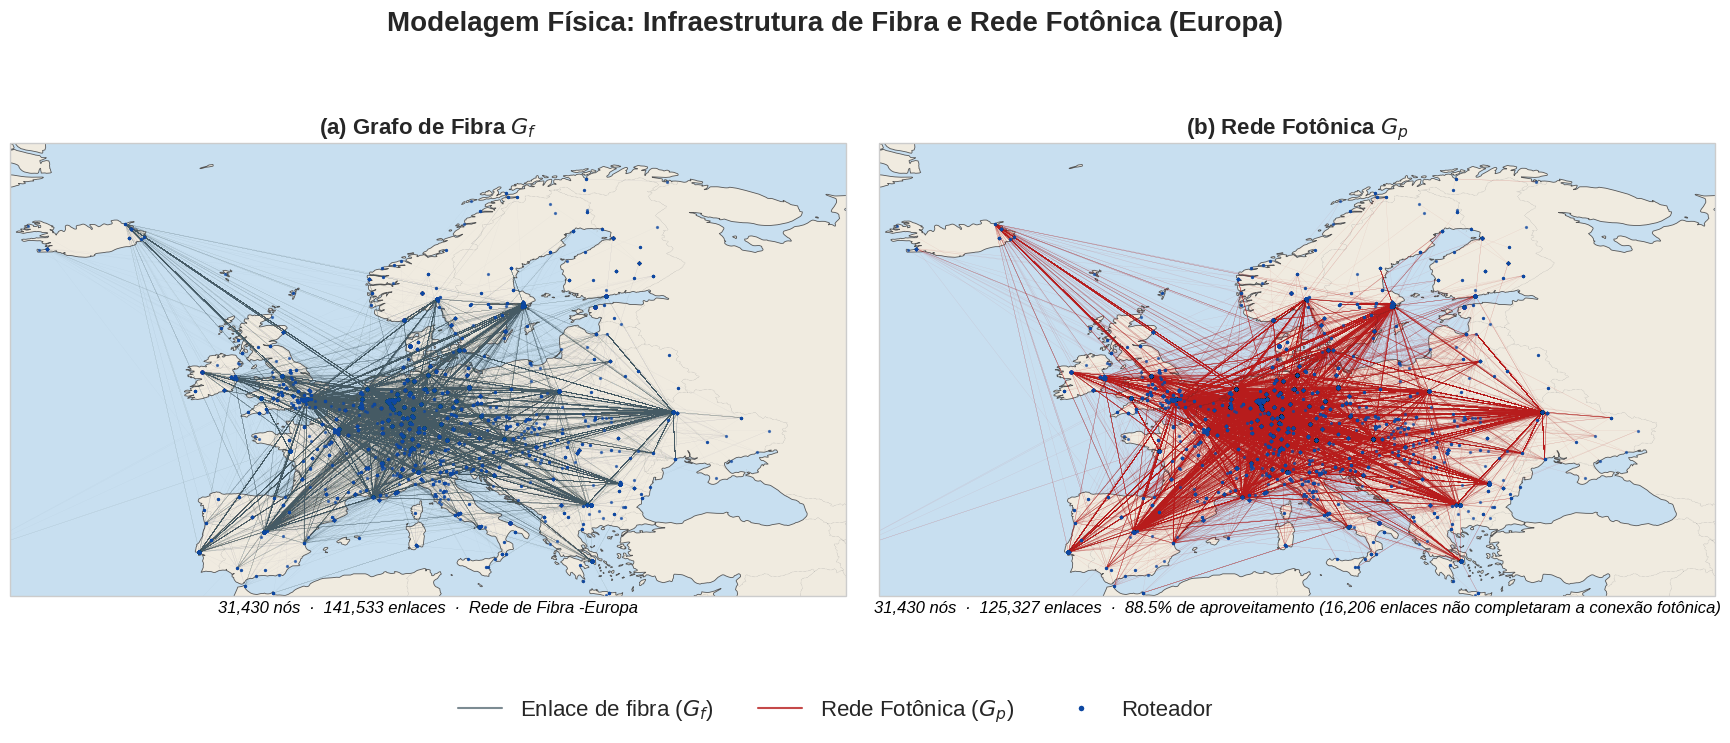

── Figura 4 concluída ──────────────────────────────────────

── Gerando Figura 5 ──────────────────────────────────────
  Limiar d* (p_uv = 0.5) = 157.9663 (unidades Euclideanas de coord.)
  Calculando distâncias dos enlaces...
  Total de enlaces analisados : 141,533
  p_uv médio                  : 1.0000
  Fração com d < d* (p_uv>0.5): 100.0%
  → Salvo: ./fig5_histograma_distancias_Europa.pdf
  → Salvo: ./fig5_histograma_distancias_Europa.png


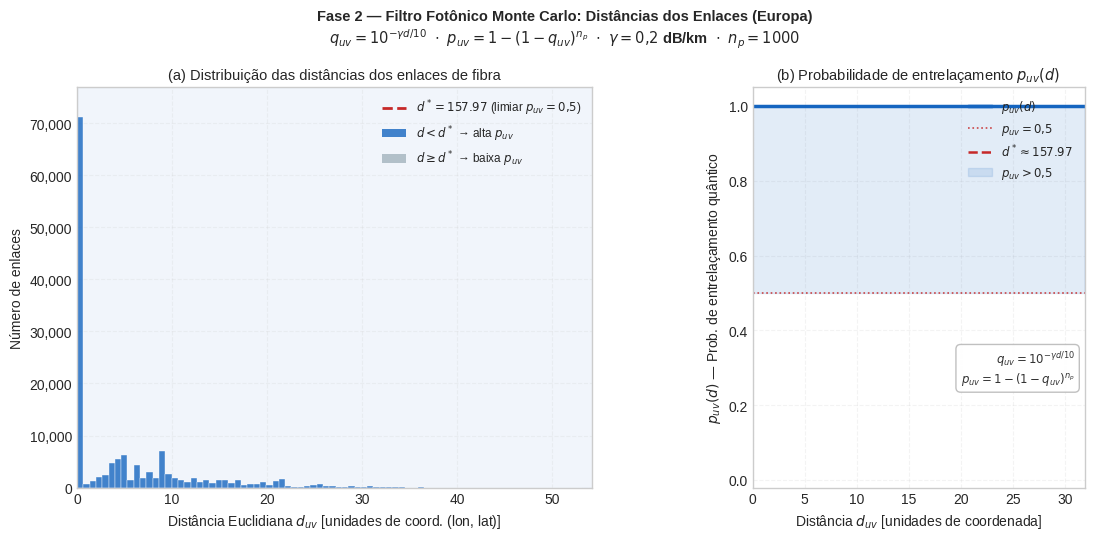

── Figura 5 concluída ──────────────────────────────────────

Todas as figuras foram geradas com sucesso.


In [10]:
# =============================================================================
#  GQ-Pipeline — Figuras 4 e 5
#  Fase 2: Modelagem Física e Quântica da Rede
#
#  FIGURA 4: Comparativo G_fibra vs. G_photonica em mapa geoespacial (Europa)
#  FIGURA 5: Histograma das distâncias dos enlaces + curva p_uv(d)
#
#  Dependências: pickle, math, numpy, matplotlib, cartopy, networkx, scipy
#
#  ── COMO USAR ───────────────────────────────────────────────────────────────
#  1. Ajuste os caminhos na seção CONFIG abaixo.
#  2. Execute no mesmo ambiente onde os .pickle foram gerados (local ou Colab).
#  3. Os PDFs e PNGs são salvos no diretório de trabalho atual.
#  ─────────────────────────────────────────────────────────────────────────────

# =============================================================================
#  SEÇÃO DE CONFIGURAÇÃO — EDITE AQUI
# =============================================================================

# ── Caminhos dos arquivos .pickle (ajuste para seu ambiente) ─────────────────


# Opção 1: Windows local
#PATH_BASE = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\Europa"

# Opção 2: Google Colab — descomente e ajuste
PATH_BASE ="/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)/"
#/content/drive/MyDrive/IC - Internet Quântica/IC - Redes Complexas (1)/Dados_redes_reais (1)/Europa (1)/g_fiber_real_EU (1).pickle
PATH_FIBRA   = os.path.join(PATH_BASE, "g_fiber_real_EU (1).pickle")
PATH_PHOTON  = os.path.join(PATH_BASE, "g_photon_real_EU (1).pickle")

# ── Parâmetros físicos do pipeline (mesmos do notebook) ─────────────────────
GAMMA   = 0.2    # dB/km — atenuação de fibra de sílica
N_P     = 1000   # fótons por pulso

# ── Extensão geográfica (lon_min, lon_max, lat_min, lat_max) ─────────────────
EXTENT_EU  = [-25, 45, 35, 73]    # Europa
NOME_CONT  = "Europa"

# ── Diretório de saída ───────────────────────────────────────────────────────
DIR_SAIDA = "."   # pasta atual; altere se quiser outro destino

def transmissivity(d: float, gamma: float = GAMMA) -> float:
    """Transmissividade do enlace: q_uv = 10^(-gamma*d/10)."""
    return 10 ** (-gamma * d / 10)


def p_photon(d: float, gamma: float = GAMMA, n_p: int = N_P) -> float:
    """Prob. de ao menos 1 fóton sobreviver: p_uv = 1-(1-q_uv)^n_p."""
    return 1.0 - (1.0 - transmissivity(d, gamma)) ** n_p


def d_limiar(target_p: float = 0.5,
             gamma: float = GAMMA, n_p: int = N_P) -> float:
    """
    Distância limiar d* onde p_uv(d*) = target_p.

    Solução analítica de p_uv = target_p:
        target_p = 1 - (1 - 10^(-gamma*d*/10))^n_p
        => d* = (-10/gamma) * log10(1 - target_p^(1/n_p))
    """
    return (-10.0 / gamma) * np.log10(1.0 - target_p ** (1.0 / n_p))


# =============================================================================
#  FUNÇÕES AUXILIARES DE PLOTAGEM
# =============================================================================

def carregar_grafos(path_fibra: str, path_photon: str):
    """Carrega G_fibra e G_photonica dos arquivos pickle."""
    print("Carregando grafos...")
    with open(path_fibra, "rb") as f:
        G_f = pickle.load(f)
    with open(path_photon, "rb") as f:
        G_p = pickle.load(f)

    # Propaga o atributo 'pos' do grafo de fibra para o fotônico
    pos = nx.get_node_attributes(G_f, "pos")
    if pos:
        nx.set_node_attributes(G_p, pos, "pos")

    print(f"  G_fibra   : {G_f.number_of_nodes():>7,} nós | {G_f.number_of_edges():>9,} arestas")
    print(f"  G_photon  : {G_p.number_of_nodes():>7,} nós | {G_p.number_of_edges():>9,} arestas")
    frac = G_p.number_of_edges() / G_f.number_of_edges() * 100
    print(f"  Taxa de sobrevivência dos enlaces: {frac:.1f}%")
    return G_f, G_p, pos


def segmentos_arestas(G: nx.Graph, pos: dict) -> list:
    """
    Extrai todos os segmentos (lon, lat) das arestas do grafo.
    Usa LineCollection para renderização vetorizada — ~100× mais rápido
    que desenhar cada aresta individualmente com ax.plot().
    """
    segs = []
    for u, v in G.edges():
        if u in pos and v in pos:
            segs.append([pos[u], pos[v]])
    return segs


def configurar_mapa(ax, extent: list, nome: str = ""):
    """Aplica o estilo visual padrão ao eixo Cartopy."""
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,
                   facecolor="#F0EBE0", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN,
                   facecolor="#C8DFF0", zorder=0)
    ax.add_feature(cfeature.COASTLINE,
                   linewidth=0.6, edgecolor="#555555", zorder=1)
    ax.add_feature(cfeature.BORDERS,
                   linewidth=0.35, edgecolor="#999999",
                   linestyle=":", zorder=1)


# =============================================================================
#  FIGURA 4 — Comparativo G_fibra vs. G_photonica
# =============================================================================

def figura4_comparativo_redes(
    G_fibra, G_photon, pos,
    extent=EXTENT_EU,
    nome_continente=NOME_CONT,
    dir_saida=DIR_SAIDA
):
    """
    Gera um painel 1×2 com:
      (a) Grafo de fibra G_f — todos os backbones intra-continentais
      (b) Rede fotônica G_p — apenas enlaces que sobreviveram ao filtro Monte Carlo

    Usa LineCollection para alta performance mesmo em grafos com 10k+ arestas.
    """
    print("\n── Gerando Figura 4 ──────────────────────────────────────")

    n_nos       = G_fibra.number_of_nodes()
    e_fibra     = G_fibra.number_of_edges()
    e_photon    = G_photon.number_of_edges()
    pct         = 100.0 * e_photon / e_fibra if e_fibra > 0 else 0.0
    n_podados   = e_fibra - e_photon

    # ── Layout ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2, figsize=(22, 7),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.04}
    )
    ax_f, ax_p = axes

    fig.suptitle(
        f"Modelagem Física: Infraestrutura de Fibra e Rede Fotônica"
        f" ({nome_continente})",
        fontsize=20, fontweight="bold", y=1.01
    )

    # Linha de parâmetros físicos abaixo do título
    '''param_str = (
        r"$q_{uv} = 10^{-\gamma d/10}$"
        r"  $\cdot$  "
        r"$p_{uv} = 1-(1-q_{uv})^{n_p}$"
        r"  $\cdot$  "
        r"$\gamma = 0{,}2$ dB/km"
        r"  $\cdot$  "
        r"$n_p = 1000$ fótons/pulso"
    )
    fig.text(0.5, 1.04,
             ha="center", fontsize=8.5, color="#555555",
             transform=fig.transFigure) '''

    # ── Painel (a): G_fibra ──────────────────────────────────────────────────
    configurar_mapa(ax_f, extent)

    segs_f = segmentos_arestas(G_fibra, pos)
    lc_f   = LineCollection(
        segs_f,
        colors="#455A64", linewidths=0.1, alpha=0.1,
        transform=ccrs.PlateCarree(), zorder=2
    )
    ax_f.add_collection(lc_f)

    # Nós
    lons_f = [pos[n][0] for n in G_fibra.nodes() if n in pos]
    lats_f = [pos[n][1] for n in G_fibra.nodes() if n in pos]
    ax_f.scatter(lons_f, lats_f, s=1.8, color="#0D47A1", alpha=0.65,
                 transform=ccrs.PlateCarree(), zorder=3)

    ax_f.set_title(r"(a) Grafo de Fibra $G_f$",
                   fontsize=16, fontweight="bold", pad=7)
    ax_f.text(
        0.5, -0.035,
        f"{n_nos:,} nós  ·  {e_fibra:,} enlaces  ·  Rede de Fibra -{nome_continente}",
        transform=ax_f.transAxes, ha="center", fontsize=12,
        color="#000000", style="italic"
    )

    # ── Painel (b): G_photonica ──────────────────────────────────────────────
    configurar_mapa(ax_p, extent)

    segs_p = segmentos_arestas(G_photon, pos)
    lc_p   = LineCollection(
        segs_p,
        colors="#B71C1C", linewidths=0.20, alpha=0.15,
        transform=ccrs.PlateCarree(), zorder=2
    )
    ax_p.add_collection(lc_p)

    # Nós (mesmo conjunto, mesma posição)
    ax_p.scatter(lons_f, lats_f, s=1.8, color="#0D47A1", alpha=0.65,
                 transform=ccrs.PlateCarree(), zorder=3)

    ax_p.set_title(r"(b) Rede Fotônica $G_p$",
                   fontsize=16, fontweight="bold", pad=7)
    ax_p.text(
        0.5, -0.035,
        (f"{G_photon.number_of_nodes():,} nós  ·  {e_photon:,} enlaces  ·  "
         f"{pct:.1f}% de aproveitamento ({n_podados:,} enlaces não completaram a conexão fotônica)"),
        transform=ax_p.transAxes, ha="center", fontsize=12,
        color="#000000", style="italic"
    )

    # ── Legenda compartilhada ────────────────────────────────────────────────
    legend_handles = [
        Line2D([0], [0], color="#455A64", lw=1.5, alpha=0.7,
               label=r"Enlace de fibra ($G_f$)"),
        Line2D([0], [0], color="#B71C1C", lw=1.5, alpha=0.8,
               label=r"Rede Fotônica ($G_p$)"),
        Line2D([0], [0], marker="o", color="w", markersize=5,
               markerfacecolor="#0D47A1", label="Roteador"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=3, fontsize=16,
        framealpha=0.92, edgecolor="#cccccc",
        bbox_to_anchor=(0.5, -0.04)
    )

    # ── Salvar ───────────────────────────────────────────────────────────────
    nome_base = f"fig4_fibra_vs_photonica_{nome_continente}"
    for ext in ("pdf", "png"):
        caminho = os.path.join(dir_saida, f"{nome_base}.{ext}")
        dpi = 300 if ext == "pdf" else 200
        plt.savefig(caminho, dpi=dpi, bbox_inches="tight")
        print(f"  → Salvo: {caminho}")

    plt.show()
    plt.close()
    print("── Figura 4 concluída ──────────────────────────────────────")


# =============================================================================
#  FIGURA 5 — Histograma das distâncias + curva p_uv(d)
# =============================================================================

def figura5_histograma_distancias(
    G_fibra, pos,
    nome_continente=NOME_CONT,
    dir_saida=DIR_SAIDA
):
    """
    Gera um painel 1×2 com:
      (a) Histograma de d_uv (distância Euclidiana em coordenadas lat/lon)
          com as barras coloridas por região (d < d* em azul, d ≥ d* em cinza)
          e linha vertical marcando d* onde p_uv = 0.5.
      (b) Curva analítica p_uv(d) com região de alta probabilidade sombreada.

    O limiar d* é calculado analiticamente das Equações 1 e 2 do TCC.
    """
    print("\n── Gerando Figura 5 ──────────────────────────────────────")

    # ── Calcular d* analiticamente ───────────────────────────────────────────
    d_star = d_limiar(target_p=0.5)
    print(f"  Limiar d* (p_uv = 0.5) = {d_star:.4f} (unidades Euclideanas de coord.)")

    # ── Calcular distâncias Euclideanas de todos os enlaces ──────────────────
    print("  Calculando distâncias dos enlaces...")
    distancias = np.array([
        math.dist(pos[u], pos[v])
        for u, v in G_fibra.edges()
        if u in pos and v in pos
    ])
    p_uvs = np.vectorize(p_photon)(distancias)

    n_total     = len(distancias)
    n_curtos    = np.sum(distancias < d_star)
    frac_curtos = n_curtos / n_total if n_total > 0 else 0.0
    p_medio     = p_uvs.mean()

    print(f"  Total de enlaces analisados : {n_total:,}")
    print(f"  p_uv médio                  : {p_medio:.4f}")
    print(f"  Fração com d < d* (p_uv>0.5): {frac_curtos*100:.1f}%")

    # ── Layout ───────────────────────────────────────────────────────────────
    fig, (ax_h, ax_c) = plt.subplots(
        1, 2, figsize=(13, 5.2),
        gridspec_kw={"width_ratios": [1.55, 1], "wspace": 0.38}
    )

    fig.suptitle(
        f"Fase 2 — Filtro Fotônico Monte Carlo: Distâncias dos Enlaces ({nome_continente})\n"
        r"$q_{uv}=10^{-\gamma d/10}$"
        r"  $\cdot$  "
        r"$p_{uv}=1-(1-q_{uv})^{n_p}$"
        r"  $\cdot$  "
        r"$\gamma=0{,}2$ dB/km  $\cdot$  $n_p=1000$",
        fontsize=10.5, fontweight="bold", y=1.03
    )

    # ─── Painel (a): Histograma das distâncias ────────────────────────────
    N_BINS = 80
    counts, bins, patches = ax_h.hist(
        distancias, bins=N_BINS,
        color="#546E7A", alpha=0.0,  # alpha=0 para colorir manualmente abaixo
        edgecolor="white", linewidth=0.35
    )

    # Colorir barras por região
    for patch, esquerda in zip(patches, bins[:-1]):
        if esquerda < d_star:
            patch.set_facecolor("#1565C0")   # azul  → d < d*, p_uv > 0.5
            patch.set_alpha(0.80)
        else:
            patch.set_facecolor("#90A4AE")   # cinza → d ≥ d*, p_uv < 0.5
            patch.set_alpha(0.65)

    y_max = counts.max() * 1.08

    # Sombreamento da região de alta probabilidade
    ax_h.axvspan(0, d_star, alpha=0.06, color="#1565C0", zorder=0)

    # Linha vertical em d*
    ax_h.axvline(
        d_star, color="#C62828", linewidth=2.0, linestyle="--",
        label=fr"$d^* = {d_star:.2f}$ (limiar $p_{{uv}}=0{{,}}5$)"
    )

    # Anotações de fração
    ax_h.annotate(
        f"{frac_curtos*100:.1f}%\n" r"($p_{uv} > 0{,}5$)",
        xy=(d_star * 0.48, y_max * 0.76),
        ha="center", va="center", fontsize=9,
        color="#1565C0", fontweight="bold",
        arrowprops=None
    )
    ax_h.annotate(
        f"{(1-frac_curtos)*100:.1f}%\n" r"($p_{uv} < 0{,}5$)",
        xy=(d_star + (distancias.max() - d_star) * 0.45, y_max * 0.76),
        ha="center", va="center", fontsize=9,
        color="#546E7A", fontweight="bold"
    )

    # Rótulo do eixo x em duas linhas para clareza
    ax_h.set_xlabel(
        r"Distância Euclidiana $d_{uv}$ [unidades de coord. (lon, lat)]",
        fontsize=10
    )
    ax_h.set_ylabel("Número de enlaces", fontsize=10)
    ax_h.set_title("(a) Distribuição das distâncias dos enlaces de fibra",
                   fontsize=10.5)
    ax_h.set_xlim(left=0, right=distancias.max() * 1.02)
    ax_h.set_ylim(0, y_max)
    ax_h.legend(fontsize=9, loc="upper right")
    ax_h.grid(True, alpha=0.22, linestyle="--", which="both")
    ax_h.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    # Legenda de cores manuais
    patch_azul  = plt.Rectangle((0,0), 1, 1, fc="#1565C0", alpha=0.80,
                                 label=r"$d < d^*$ → alta $p_{uv}$")
    patch_cinza = plt.Rectangle((0,0), 1, 1, fc="#90A4AE", alpha=0.65,
                                 label=r"$d \geq d^*$ → baixa $p_{uv}$")
    ax_h.legend(
        handles=[
            ax_h.lines[0],  # linha d*
            patch_azul,
            patch_cinza
        ],
        fontsize=8.5, loc="upper right",
        framealpha=0.92, edgecolor="#cccccc"
    )

    # ─── Painel (b): Curva p_uv(d) ───────────────────────────────────────
    # Zoom na região relevante (até 2× d*)
    d_max_plot = min(d_star * 3.5, distancias.max() * 0.6)
    d_range    = np.linspace(0, d_max_plot, 600)
    p_range    = np.vectorize(p_photon)(d_range)

    ax_c.plot(d_range, p_range, color="#1565C0", linewidth=2.5,
              label=r"$p_{uv}(d)$")

    # Linha horizontal em p=0.5
    ax_c.axhline(0.5, color="#C62828", linewidth=1.2, linestyle=":",
                 alpha=0.85, label=r"$p_{uv} = 0{{,}}5$")

    # Linha vertical em d*
    ax_c.axvline(d_star, color="#C62828", linewidth=1.8, linestyle="--",
                 label=fr"$d^* \approx {d_star:.2f}$ ")

    # Ponto de interseção
    ax_c.scatter([d_star], [0.5], color="#C62828", s=60, zorder=6)

    # Anotação do ponto de interseção
    ax_c.annotate(
        fr"$(d^*,\; 0{{,}}5)$",
        xy=(d_star, 0.5),
        xytext=(d_star + d_max_plot * 0.08, 0.55),
        fontsize=8.5, color="#C62828",
        arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.2)
    )

    # Região de alta prob. (sombreamento abaixo da curva para d < d*)
    mask = d_range <= d_star
    ax_c.fill_between(d_range[mask], p_range[mask], 0.5,
                      alpha=0.12, color="#1565C0",
                      label=r"$p_{uv} > 0{{,}}5$")

    # Box com as equações
    eq_txt = (
        r"$q_{uv} = 10^{-\gamma d / 10}$" "\n"
        r"$p_{uv} = 1-(1-q_{uv})^{n_p}$"
    )
    ax_c.text(
        0.97, 0.25, eq_txt,
        transform=ax_c.transAxes, ha="right", va="bottom",
        fontsize=8.5, color="#333333",
        bbox=dict(facecolor="white", edgecolor="#BBBBBB",
                  boxstyle="round,pad=0.4", alpha=0.92)
    )

    ax_c.set_xlabel(r"Distância $d_{uv}$ [unidades de coordenada]", fontsize=10)
    ax_c.set_ylabel(
        r"$p_{uv}(d)$ — Prob. de entrelaçamento quântico", fontsize=10
    )
    ax_c.set_title(
        r"(b) Probabilidade de entrelaçamento $p_{uv}(d)$",
        fontsize=10.5
    )
    ax_c.set_xlim(0, d_max_plot)
    ax_c.set_ylim(-0.02, 1.05)
    ax_c.legend(fontsize=8.5, loc="upper right",
                framealpha=0.92, edgecolor="#cccccc")
    ax_c.grid(True, alpha=0.22, linestyle="--")

    # ── Salvar ───────────────────────────────────────────────────────────────
    nome_base = f"fig5_histograma_distancias_{nome_continente}"
    for ext in ("pdf", "png"):
        caminho = os.path.join(dir_saida, f"{nome_base}.{ext}")
        dpi = 300 if ext == "pdf" else 200
        plt.savefig(caminho, dpi=dpi, bbox_inches="tight")
        print(f"  → Salvo: {caminho}")

    plt.show()
    plt.close()
    print("── Figura 5 concluída ──────────────────────────────────────")


# =============================================================================
#  EXECUÇÃO PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    # ── 1. Carregar os grafos ─────────────────────────────────────────────────
    G_fibra, G_photon, pos = carregar_grafos(PATH_FIBRA, PATH_PHOTON)

    # ── 2. Figura 4 ───────────────────────────────────────────────────────────
    figura4_comparativo_redes(
        G_fibra=G_fibra,
        G_photon=G_photon,
        pos=pos,
        extent=EXTENT_EU,
        nome_continente=NOME_CONT,
        dir_saida=DIR_SAIDA
    )

    # ── 3. Figura 5 ───────────────────────────────────────────────────────────
    figura5_histograma_distancias(
        G_fibra=G_fibra,
        pos=pos,
        nome_continente=NOME_CONT,
        dir_saida=DIR_SAIDA
    )

    print("\nTodas as figuras foram geradas com sucesso.")
